### Simple Sub-Graph Analysis Network

In [3]:
import random
import time

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import Markdown, display
from y0.algorithm.identify import Unidentifiable
from y0.algorithm.identify.cyclic_id import cyclic_id
from y0.algorithm.ioscm.utils import (
    get_apt_order,
    get_graph_consolidated_districts,
    get_strongly_connected_components,
)
from y0.dsl import Variable
from y0.graph import NxMixedGraph

In [9]:
# ============================================================================
# Create the 5-node stress response network
# ============================================================================

display(Markdown("## Step 1: Network Construction"))

nodes = ["fur", "fnr", "soxR", "oxyR", "soxS"]

edges = [
    ("oxyR", "fur"),
    ("fur", "soxR"),
    ("soxR", "oxyR"),
    ("soxR", "soxS"),
    ("fnr", "soxR"),
    ("fnr", "fnr"),  # self-loop
]

# Create NxMixedGraph directly
stress_graph = NxMixedGraph.from_edges(directed=edges)

display(
    Markdown(f"""
**Network Properties:**
- Nodes: {len(stress_graph.nodes())}
- Edges: {len(list(stress_graph.directed.edges()))}
- Key cycle: fur → soxR → oxyR → fur (3-gene feedback loop)
""")
)

display(Markdown("**Edge List:**"))
edges_df = pd.DataFrame(sorted(edges), columns=["Source", "Target"])
edges_df["Note"] = edges_df.apply(
    lambda row: "self-loop" if row["Source"] == row["Target"] else "", axis=1
)
display(edges_df)

## Step 1: Network Construction


**Network Properties:**
- Nodes: 5
- Edges: 6
- Key cycle: fur → soxR → oxyR → fur (3-gene feedback loop)


**Edge List:**

,Source,Target,Note
0,fnr,fnr,self-loop
1,fnr,soxR,
2,fur,soxR,
3,oxyR,fur,
4,soxR,oxyR,
5,soxR,soxS,


In [10]:
# ============================================================================
# Analyze graph structure
# ============================================================================

display(Markdown("## Step 2: Graph Analysis"))

# Get SCCs
sccs = get_strongly_connected_components(stress_graph)
sccs_sorted = sorted(sccs, key=len, reverse=True)

display(Markdown(f"**Strongly Connected Components:** {len(sccs)}"))
sccs_data = []
for i, scc in enumerate(sccs_sorted, 1):
    sccs_data.append(
        {"SCC": i, "Nodes": ", ".join(sorted([str(v) for v in scc])), "Size": len(scc)}
    )
sccs_df = pd.DataFrame(sccs_data)
display(sccs_df)

# Get consolidated districts
consolidated_districts = get_graph_consolidated_districts(stress_graph)
cds_sorted = sorted(consolidated_districts, key=len, reverse=True)

display(Markdown(f"\n**Consolidated Districts:** {len(consolidated_districts)}"))
cds_data = []
for i, cd in enumerate(cds_sorted, 1):
    cds_data.append(
        {"District": i, "Nodes": ", ".join(sorted([str(v) for v in cd])), "Size": len(cd)}
    )
cds_df = pd.DataFrame(cds_data)
display(cds_df)

## Step 2: Graph Analysis

**Strongly Connected Components:** 3

,SCC,Nodes,Size
0,1,"fur, oxyR, soxR",3
1,2,fnr,1
2,3,soxS,1



**Consolidated Districts:** 3

,District,Nodes,Size
0,1,"fur, oxyR, soxR",3
1,2,fnr,1
2,3,soxS,1


In [11]:
# ============================================================================
# Generate apt-order
# ============================================================================

display(Markdown("## Step 3: Apt-Order Generation"))

apt_order = get_apt_order(stress_graph)

display(Markdown("**Apt-order (total ordering of variables):**"))
apt_order_df = pd.DataFrame(
    {"Position": range(1, len(apt_order) + 1), "Variable": [str(v) for v in apt_order]}
)
display(apt_order_df)

display(Markdown(f"\n**Ordering:** {' < '.join([str(v) for v in apt_order])}"))

## Step 3: Apt-Order Generation

**Apt-order (total ordering of variables):**

,Position,Variable
0,1,fnr
1,2,fur
2,3,oxyR
3,4,soxR
4,5,soxS



**Ordering:** fnr < fur < oxyR < soxR < soxS

In [7]:
# ============================================================================
# Define and test the queries from the example graph
# ============================================================================

display(Markdown("## Step 4: Testing Queries"))

# Define queries
queries = [
    {
        "notation": "P(soxS | do(fnr))",
        "intervention_genes": ["fnr"],
        "outcome_genes": ["soxS"],
        "explanation": "fnr outside 3-gene cycle",
    },
    {
        "notation": "P(oxyR | do(fnr))",
        "intervention_genes": ["fnr"],
        "outcome_genes": ["oxyR"],
        "explanation": "fnr outside 3-gene cycle",
    },
    {
        "notation": "P(oxyR | do(fur))",
        "intervention_genes": ["fur"],
        "outcome_genes": ["oxyR"],
        "explanation": "Both in 3-gene cycle",
    },
    {
        "notation": "P(soxS | do(fnr, fur))",
        "intervention_genes": ["fnr", "fur"],
        "outcome_genes": ["soxS"],
        "explanation": "Interventions outside soxS district",
    },
    {
        "notation": "P(oxyR | do(fur, soxR))",
        "intervention_genes": ["fur", "soxR"],
        "outcome_genes": ["oxyR"],
        "explanation": "Both interventions in same cycle",
    },
    {
        "notation": "P(oxyR, soxS | do(fnr))",
        "intervention_genes": ["fnr"],
        "outcome_genes": ["oxyR", "soxS"],
        "explanation": "fnr outside cycle, both reachable",
    },
]

# Test each query
results = []

for idx, query_info in enumerate(queries, 1):
    display(Markdown(f"### Query {idx}: `{query_info['notation']}`"))

    # Create variables
    interventions = [Variable(g) for g in query_info["intervention_genes"]]
    outcomes = [Variable(g) for g in query_info["outcome_genes"]]

    # Time the computation
    start_time = time.time()

    try:
        result = cyclic_id(
            graph=stress_graph,
            outcomes=outcomes[0] if len(outcomes) == 1 else outcomes,
            interventions=interventions[0] if len(interventions) == 1 else interventions,
            ordering=apt_order,
        )

        result = "IDENTIFIABLE"
        estimand_str = str(result)
        error_msg = None

        display(
            Markdown(
                "**Result:** <span style='color: green; font-weight: bold;'>✓ IDENTIFIABLE</span>"
            )
        )
        display(Markdown(f"**Explanation:** {query_info['explanation']}"))
        display(Markdown(f"**Runtime:** {time.time() - start_time:.4f}s"))
        display(Markdown("**Estimand:**"))
        display(result)

    except Unidentifiable as e:
        result = "UNIDENTIFIABLE"
        estimand_str = None
        error_msg = str(e)

        display(
            Markdown(
                "**Result:** <span style='color: red; font-weight: bold;'>✗ UNIDENTIFIABLE</span>"
            )
        )
        display(Markdown(f"**Explanation:** {query_info['explanation']}"))
        display(Markdown(f"**Runtime:** {time.time() - start_time:.4f}s"))
        display(Markdown(f"**Error:** {error_msg[:200]}"))

    except Exception as e:
        result = "ERROR"
        estimand_str = None
        error_msg = f"{type(e).__name__}: {e!s}"

        display(
            Markdown("**Result:** <span style='color: orange; font-weight: bold;'>⚠ ERROR</span>")
        )
        display(Markdown(f"**Error:** {error_msg[:200]}"))

    runtime = time.time() - start_time

    # Store results
    results.append(
        {
            "query_num": idx,
            "notation": query_info["notation"],
            "interventions": ", ".join(query_info["intervention_genes"]),
            "outcomes": ", ".join(query_info["outcome_genes"]),
            "result": result,
            "explanation": query_info["explanation"],
            "runtime": runtime,
            "estimand_length": len(estimand_str) if estimand_str else None,
            "estimand": estimand_str,
            "error": error_msg,
        }
    )

    display(Markdown("---"))

results_df = pd.DataFrame(results)
display(Markdown("### Results Summary"))
display(results_df)

## Step 4: Testing Queries

### Query 1: `P(soxS | do(fnr))`

**Result:** <span style='color: red; font-weight: bold;'>✗ UNIDENTIFIABLE</span>

**Explanation:** fnr outside 3-gene cycle

**Runtime:** 0.0070s

...

**Runtime:** 0.0066s

**Error:** Cannot identify P{oxyR, soxS} | do{fnr})). District frozenset({fur, oxyR, soxR}) failed identification.

---

### Results Summary

,query_num,notation,interventions,outcomes,result,explanation,runtime,estimand_length,estimand,error
0,1,P(soxS | do(fnr)),fnr,soxS,UNIDENTIFIABLE,fnr outside 3-gene cycle,0.009319,None,None,Cannot identify P{soxS} | do{fnr})). District ...
1,2,P(oxyR | do(fnr)),fnr,oxyR,UNIDENTIFIABLE,fnr outside 3-gene cycle,0.015177,None,None,Cannot identify P{oxyR} | do{fnr})). District ...
2,3,P(oxyR | do(fur)),fur,oxyR,UNIDENTIFIABLE,Both in 3-gene cycle,0.013110,None,None,Cannot identify P{oxyR} | do{fur})). District ...
3,4,"P(soxS | do(fnr, fur))","fnr, fur",soxS,UNIDENTIFIABLE,Interventions outside soxS district,0.011741,None,None,"Cannot identify P{soxS} | do{fur, fnr})). Dist..."
4,5,"P(oxyR | do(fur, soxR))","fur, soxR",oxyR,UNIDENTIFIABLE,Both interventions in same cycle,0.013078,None,None,"Cannot identify P{oxyR} | do{fur, soxR})). Dis..."
5,6,"P(oxyR, soxS | do(fnr))",fnr,"oxyR, soxS",UNIDENTIFIABLE,"fnr outside cycle, both reachable",0.011175,None,None,"Cannot identify P{oxyR, soxS} | do{fnr})). Dis..."


In [8]:
# ============================================================================
# Summary statistics
# ============================================================================

display(Markdown("## Step 5: Summary Statistics"))

identifiable_count = (results_df["result"] == "IDENTIFIABLE").sum()
unidentifiable_count = (results_df["result"] == "UNIDENTIFIABLE").sum()
total_count = len(results_df)

# Overall statistics
overall_stats = pd.DataFrame(
    {
        "Metric": ["Total Queries", "Identifiable", "Unidentifiable", "Identifiable %"],
        "Value": [
            total_count,
            identifiable_count,
            unidentifiable_count,
            f"{100 * identifiable_count / total_count:.1f}%",
        ],
    }
)
display(Markdown("**Overall Results:**"))
display(overall_stats)

# Runtime statistics
runtime_stats = pd.DataFrame(
    {
        "Metric": ["Mean", "Median", "Min", "Max", "Total"],
        "Runtime (seconds)": [
            f"{results_df['runtime'].mean():.4f}",
            f"{results_df['runtime'].median():.4f}",
            f"{results_df['runtime'].min():.4f}",
            f"{results_df['runtime'].max():.4f}",
            f"{results_df['runtime'].sum():.4f}",
        ],
    }
)
display(Markdown("\n**Runtime Statistics:**"))
display(runtime_stats)

# Breakdown by query type
single_gene = results_df[~results_df["interventions"].str.contains(",")]
multi_gene = results_df[results_df["interventions"].str.contains(",")]

breakdown_stats = pd.DataFrame(
    {
        "Query Type": ["Single-gene", "Single-gene", "Multi-gene", "Multi-gene"],
        "Result": ["Identifiable", "Unidentifiable", "Identifiable", "Unidentifiable"],
        "Count": [
            (single_gene["result"] == "IDENTIFIABLE").sum(),
            (single_gene["result"] == "UNIDENTIFIABLE").sum(),
            (multi_gene["result"] == "IDENTIFIABLE").sum(),
            (multi_gene["result"] == "UNIDENTIFIABLE").sum(),
        ],
    }
)
display(Markdown("\n**Breakdown by Query Type:**"))
display(breakdown_stats)

## Step 5: Summary Statistics

**Overall Results:**

,Metric,Value
0,Total Queries,6
1,Identifiable,0
2,Unidentifiable,6
3,Identifiable %,0.0%



**Runtime Statistics:**

,Metric,Runtime (seconds)
0,Mean,0.0123
1,Median,0.0124
2,Min,0.0093
3,Max,0.0152
4,Total,0.0736



**Breakdown by Query Type:**

,Query Type,Result,Count
0,Single-gene,Identifiable,0
1,Single-gene,Unidentifiable,4
2,Multi-gene,Identifiable,0
3,Multi-gene,Unidentifiable,2


## Full E. coli Network Analysis & Visualizations for Presentation
---


In [4]:
import time
from datetime import datetime

import pandas as pd
from IPython.display import Markdown, display
from y0.algorithm.identify import Unidentifiable
from y0.algorithm.identify.cyclic_id import cyclic_id
from y0.algorithm.ioscm.utils import (
    get_apt_order,
    get_graph_consolidated_districts,
    get_strongly_connected_components,
)

# y0 library imports
from y0.dsl import Variable
from y0.graph import NxMixedGraph

display(Markdown("# E. coli Gene Regulatory Network - Identifiability Analysis"))
display(Markdown("*Systematic analysis of all upstream→downstream intervention pairs*"))

# E. coli Gene Regulatory Network - Identifiability Analysis

*Systematic analysis of all upstream→downstream intervention pairs*

In [5]:
# ============================================================================
# Load E. coli network
# ============================================================================

display(Markdown("## Step 1: Load E. coli Network"))

# Load the GraphML file
ecoli_nx = nx.read_graphml("ecoli_full_network_no_small_rna.graphml")

display(
    Markdown(f"""
**Network loaded (NetworkX):**
- Nodes: {ecoli_nx.number_of_nodes():,}
- Edges: {ecoli_nx.number_of_edges():,}
- Is DAG: {nx.is_directed_acyclic_graph(ecoli_nx)}
""")
)

# Convert to NxMixedGraph for causal inference
ecoli_graph = NxMixedGraph.from_edges(directed=list(ecoli_nx.edges()))

display(Markdown("**✓ Converted to NxMixedGraph for causal inference**"))

# Get network properties
all_nodes = list(ecoli_graph.nodes())
display(Markdown(f"**Total nodes in y0 graph:** {len(all_nodes):,}"))

## Step 1: Load E. coli Network


**Network loaded (NetworkX):**
- Nodes: 2,976
- Edges: 9,211
- Is DAG: False


**✓ Converted to NxMixedGraph for causal inference**

**Total nodes in y0 graph:** 2,962

In [6]:
# ============================================================================
# Find all valid upstream→downstream pairs
# ============================================================================

display(Markdown("## Step 2: Finding All Valid Upstream→Downstream Pairs"))
display(Markdown("*Finding all pairs where intervention is upstream of target...*"))

# Find all valid pairs where intervention is upstream of target
valid_pairs = []

start_find = time.time()

for i, intervention_node in enumerate(all_nodes):
    if (i + 1) % 500 == 0:
        display(Markdown(f"Progress: {i + 1:,}/{len(all_nodes):,} nodes checked..."))

    # Get all descendants of this node (nodes reachable from intervention)
    try:
        descendants = nx.descendants(ecoli_nx, str(intervention_node))

        for target_node in descendants:
            # Don't include self (intervention == target)
            if str(intervention_node) != str(target_node):
                valid_pairs.append((str(intervention_node), str(target_node)))
    except:
        # Node might not be in graph or other issue
        continue

find_time = time.time() - start_find

display(
    Markdown(f"""
**✓ Search complete!**

**Results:**
- Total valid upstream→downstream pairs: **{len(valid_pairs):,}**
- Time to find pairs: {find_time:.2f}s ({find_time / 60:.2f} minutes)
- Average time per node: {find_time / len(all_nodes):.4f}s

**What this means:**
- These are all gene pairs where the intervention can causally affect the target
- Maximum possible queries to test: {len(valid_pairs):,}
""")
)

# Save valid pairs to file for later use
pairs_df = pd.DataFrame(valid_pairs, columns=["intervention", "target"])
pairs_df.to_csv("ecoli_valid_pairs.csv", index=False)
display(Markdown("**✓ Valid pairs saved to:** `ecoli_valid_pairs.csv`"))

display(Markdown("**First 10 valid pairs:**"))
display(pairs_df.head(10))

## Step 2: Finding All Valid Upstream→Downstream Pairs

*Finding all pairs where intervention is upstream of target...*

Progress: 500/2,962 nodes checked...

Progress: 1,000/2,962 nodes checked...

Progress: 1,500/2,962 nodes checked...

...

Progress: 2,500/2,962 nodes checked...


**✓ Search complete!**

**Results:**
- Total valid upstream→downstream pairs: **216,479**
- Time to find pairs: 1.26s (0.02 minutes)
- Average time per node: 0.0004s

**What this means:**
- These are all gene pairs where the intervention can causally affect the target
- Maximum possible queries to test: 216,479


**✓ Valid pairs saved to:** `ecoli_valid_pairs.csv`

**First 10 valid pairs:**

,intervention,target
0,aaeR,aaeX
1,aaeR,aaeB
2,aaeR,aaeA
3,accA,accD
4,accD,accA
5,accB,accC
6,acrR,caiA
7,acrR,atoB
8,acrR,aceK
9,acrR,umuD


In [7]:
# ============================================================================
# Generate apt-order for the entire network
# ============================================================================

display(Markdown("## Step 3: Generate Apt-Order"))

apt_order_start = time.time()
apt_order = get_apt_order(ecoli_graph)
apt_order_time = time.time() - apt_order_start

display(
    Markdown(f"""
**✓ Apt-order generated!**
- Time to generate: {apt_order_time:.2f}s
- Total genes ordered: {len(apt_order):,}

**What this means:**
- This ordering respects all causal relationships in the network
- For any upstream→downstream pair, intervention comes before target in this ordering
- Used internally by cyclic_id for distribution factorization (Line 23)
- **Reused for all {len(valid_pairs):,} queries** (no need to regenerate)
""")
)

# Show first 10 genes in ordering
display(Markdown("**First 10 genes in apt-order:**"))
first_10 = [str(v) for v in apt_order[:10]]
display(Markdown(f"`{' < '.join(first_10)}`"))

# Show last 10 genes in ordering
display(Markdown("**Last 10 genes in apt-order:**"))
last_10 = [str(v) for v in apt_order[-10:]]
display(Markdown(f"`{' < '.join(last_10)}`"))

## Step 3: Generate Apt-Order


**✓ Apt-order generated!**
- Time to generate: 0.32s
- Total genes ordered: 2,961

**What this means:**
- This ordering respects all causal relationships in the network
- For any upstream→downstream pair, intervention comes before target in this ordering
- Used internally by cyclic_id for distribution factorization (Line 23)
- **Reused for all 216,479 queries** (no need to regenerate)


**First 10 genes in apt-order:**

`modE < glaR < atoC < nsrR < hypT < ulaR < dicD < basR < nanR < rcdA`

**Last 10 genes in apt-order:**

`hyaF < appX < appB < hyaB < hyaD < appC < hyaC < appA < hyaE < hyaA`

In [21]:
# ============================================================================
# Benchmark: 5 random pairs
# ============================================================================

display(Markdown("## Step 4: Benchmarking - Sample Sizes"))
display(Markdown("### Test 1: 5 Random Pairs"))

# Sample 5 random pairs
sample_size = 5
sample_pairs = random.sample(valid_pairs, sample_size)

display(Markdown(f"**Testing {sample_size} random upstream→downstream pairs...**"))

# Test queries
results = []

for idx, (interv_name, target_name) in enumerate(sample_pairs, 1):
    display(Markdown(f"**Query {idx}/{sample_size}:** `P({target_name} | do({interv_name}))`"))

    interv = Variable(interv_name)
    target = Variable(target_name)

    start_time = time.time()

    try:
        estimand = cyclic_id(
            graph=ecoli_graph, outcomes=target, interventions=interv, ordering=apt_order
        )

        identifiable = True
        estimand_str = str(estimand)
        error_msg = None

        display(Markdown(f"  ✓ **IDENTIFIABLE** (runtime: {time.time() - start_time:.4f}s)"))

    except Unidentifiable as e:
        identifiable = False
        estimand_str = None
        error_msg = str(e)

        display(Markdown(f"  ✗ **UNIDENTIFIABLE** (runtime: {time.time() - start_time:.4f}s)"))

    except Exception as e:
        identifiable = False
        estimand_str = None
        error_msg = f"{type(e).__name__}: {e!s}"

        display(Markdown(f"  ⚠ **ERROR** (runtime: {time.time() - start_time:.4f}s)"))

    runtime = time.time() - start_time

    results.append(
        {
            "sample_size": sample_size,
            "pair_id": idx,
            "intervention": interv_name,
            "target": target_name,
            "identifiable": identifiable,
            "runtime_seconds": runtime,
            "estimand_length": len(estimand_str) if estimand_str else None,
            "estimand": estimand_str,
            "error_message": error_msg,
        }
    )

results_5_df = pd.DataFrame(results)

# Summary
identifiable_count = results_5_df["identifiable"].sum()
total_runtime = results_5_df["runtime_seconds"].sum()
avg_runtime = results_5_df["runtime_seconds"].mean()

display(
    Markdown(f"""
---
**✓ 5-pair sample complete!**

**Results:**
- Identifiable: {identifiable_count}/{sample_size} ({100 * identifiable_count / sample_size:.1f}%)
- Unidentifiable: {sample_size - identifiable_count}/{sample_size} ({100 * (sample_size - identifiable_count) / sample_size:.1f}%)

**Runtime:**
- Total: {total_runtime:.4f}s
- Average per query: {avg_runtime:.4f}s
- Min: {results_5_df["runtime_seconds"].min():.4f}s
- Max: {results_5_df["runtime_seconds"].max():.4f}s
""")
)

display(results_5_df)

# Save results
results_5_df.to_csv("ecoli_benchmark_5pairs.csv", index=False)
display(Markdown("**✓ Results saved:** `ecoli_benchmark_5pairs.csv`"))

## Step 4: Benchmarking - Sample Sizes

### Test 1: 5 Random Pairs

**Testing 5 random upstream→downstream pairs...**

**Query 1/5:** `P(def | do(ihfA))`

  ✗ **UNIDENTIFIABLE** (runtime: 27.3786s)

...

**Query 5/5:** `P(yehW | do(glaR))`

  ✓ **IDENTIFIABLE** (runtime: 33.3981s)


---
**✓ 5-pair sample complete!**

**Results:**
- Identifiable: 1/5 (20.0%)
- Unidentifiable: 4/5 (80.0%)

**Runtime:**
- Total: 145.6478s
- Average per query: 29.1296s
- Min: 16.9750s
- Max: 44.4137s


,sample_size,pair_id,intervention,target,identifiable,runtime_seconds,estimand_length,estimand,error_message
0,5,1,ihfA,def,False,27.380293,NaN,None,Cannot identify P{def} | do{ihfA})). District ...
1,5,2,phoB,ppiB,False,16.975003,NaN,None,Cannot identify P{ppiB} | do{phoB})). District...
2,5,3,soxR,ulaF,False,44.413747,NaN,None,Cannot identify P{ulaF} | do{soxR})). District...
3,5,4,bglJ,ybhI,False,23.470804,NaN,None,Cannot identify P{ybhI} | do{bglJ})). District...
4,5,5,glaR,yehW,True,33.407986,17522.0,"Sum[acrR, adiY, alpA, arcA, argP, argR, basR, ...",None


**✓ Results saved:** `ecoli_benchmark_5pairs.csv`

In [22]:
# ============================================================================
# Benchmark: 50 random pairs
# ============================================================================

display(Markdown("### Test 2: 50 Random Pairs"))

# Sample 50 random pairs (different from the 5-pair sample)
sample_size = 50
sample_pairs = random.sample(valid_pairs, sample_size)

display(Markdown(f"**Testing {sample_size} random upstream→downstream pairs...**"))
display(
    Markdown(f"*Estimated time: ~{sample_size * 29.13 / 60:.1f} minutes based on 5-pair average*")
)

# Test queries
results_50 = []
start_batch = time.time()

for idx, (interv_name, target_name) in enumerate(sample_pairs, 1):
    if idx % 10 == 0:
        elapsed = time.time() - start_batch
        avg_so_far = elapsed / idx
        remaining = (sample_size - idx) * avg_so_far
        display(
            Markdown(
                f"Progress: **{idx}/{sample_size}** | Elapsed: {elapsed / 60:.1f}min | Est. remaining: {remaining / 60:.1f}min"
            )
        )

    interv = Variable(interv_name)
    target = Variable(target_name)

    start_time = time.time()

    try:
        estimand = cyclic_id(
            graph=ecoli_graph, outcomes=target, interventions=interv, ordering=apt_order
        )

        identifiable = True
        estimand_str = str(estimand)
        error_msg = None

    except Unidentifiable as e:
        identifiable = False
        estimand_str = None
        error_msg = str(e)

    except Exception as e:
        identifiable = False
        estimand_str = None
        error_msg = f"{type(e).__name__}: {e!s}"

    runtime = time.time() - start_time

    results_50.append(
        {
            "sample_size": sample_size,
            "pair_id": idx,
            "intervention": interv_name,
            "target": target_name,
            "identifiable": identifiable,
            "runtime_seconds": runtime,
            "estimand_length": len(estimand_str) if estimand_str else None,
            "estimand": estimand_str[:500] if estimand_str else None,
            "error_message": error_msg[:500] if error_msg else None,
        }
    )

results_50_df = pd.DataFrame(results_50)

# Summary
identifiable_count = results_50_df["identifiable"].sum()
total_runtime = results_50_df["runtime_seconds"].sum()
avg_runtime = results_50_df["runtime_seconds"].mean()

display(
    Markdown(f"""
---
**✓ 50-pair sample complete!**

**Results:**
- Identifiable: {identifiable_count}/{sample_size} ({100 * identifiable_count / sample_size:.1f}%)
- Unidentifiable: {sample_size - identifiable_count}/{sample_size} ({100 * (sample_size - identifiable_count) / sample_size:.1f}%)

**Runtime:**
- Total: {total_runtime:.2f}s ({total_runtime / 60:.2f} minutes)
- Average per query: {avg_runtime:.4f}s
- Min: {results_50_df["runtime_seconds"].min():.4f}s
- Max: {results_50_df["runtime_seconds"].max():.4f}s

**Comparison with 5-pair sample:**
- 5-pair: 1/5 identifiable (20.0%)
- 50-pair: {identifiable_count}/{sample_size} identifiable ({100 * identifiable_count / sample_size:.1f}%)
""")
)

display(
    results_50_df[["pair_id", "intervention", "target", "identifiable", "runtime_seconds"]].head(20)
)

# Save results
results_50_df.to_csv("ecoli_benchmark_50pairs.csv", index=False)
display(Markdown("**✓ Results saved:** `ecoli_benchmark_50pairs.csv`"))

# Projection for 500 pairs
est_500_hours = (500 * avg_runtime) / 3600
display(
    Markdown(f"""
### Projection for 500-pair test:
- Estimated total time: **{est_500_hours:.2f} hours**
""")
)

### Test 2: 50 Random Pairs

**Testing 50 random upstream→downstream pairs...**

*Estimated time: ~24.3 minutes based on 5-pair average*

Progress: **10/50** | Elapsed: 3.3min | Est. remaining: 13.2min

Progress: **20/50** | Elapsed: 7.7min | Est. remaining: 11.6min

...

Progress: **50/50** | Elapsed: 22.2min | Est. remaining: 0.0min


---
**✓ 50-pair sample complete!**

**Results:**
- Identifiable: 10/50 (20.0%)
- Unidentifiable: 40/50 (80.0%)

**Runtime:**
- Total: 1384.17s (23.07 minutes)
- Average per query: 27.6834s
- Min: 4.7988s
- Max: 54.5857s

**Comparison with 5-pair sample:**
- 5-pair: 1/5 identifiable (20.0%)
- 50-pair: 10/50 identifiable (20.0%)


,pair_id,intervention,target,identifiable,runtime_seconds
0,1,evgA,uidC,False,18.487376
1,2,zraR,umpG,False,33.281729
2,3,adiY,yhdX,False,5.353622
3,4,nsrR,yiaO,True,43.276731
4,5,soxS,yfbL,False,18.035249
5,6,adiY,sthA,False,18.946250
6,7,ihfB,lsrR,False,22.584887
7,8,rpoH,atoD,False,22.127292
8,9,fliZ,frlA,False,16.289021
9,10,oxyR,phnK,False,38.411369


**✓ Results saved:** `ecoli_benchmark_50pairs.csv`


### Projection for 500-pair test:
- Estimated total time: **3.84 hours**


In [23]:
# ============================================================================
# Benchmark: 500 random pairs
# ============================================================================

display(Markdown("### Test 3: 500 Random Pairs"))

# Sample 500 random pairs (different from 5 and 50)
sample_size = 500
sample_pairs = random.sample(valid_pairs, sample_size)

display(Markdown(f"**Testing {sample_size} random upstream→downstream pairs...**"))
display(
    Markdown(f"*Estimated time: ~{sample_size * 27.68 / 3600:.2f} hours based on 50-pair average*")
)
display(Markdown(f"*Started: {datetime.now().strftime('%H:%M:%S')}*"))

# Test queries
results_500 = []
start_batch = time.time()

for idx, (interv_name, target_name) in enumerate(sample_pairs, 1):
    # Progress updates every 50 queries
    if idx % 50 == 0:
        elapsed = time.time() - start_batch
        avg_so_far = elapsed / idx
        remaining = (sample_size - idx) * avg_so_far
        pct_complete = 100 * idx / sample_size

        # Count identifiable so far
        identifiable_so_far = sum([r["identifiable"] for r in results_500])
        pct_id = 100 * identifiable_so_far / idx if idx > 0 else 0

        display(
            Markdown(
                f"Progress: **{idx}/{sample_size} ({pct_complete:.1f}%)** | "
                f"Identifiable so far: {identifiable_so_far}/{idx} ({pct_id:.1f}%) | "
                f"Elapsed: {elapsed / 60:.1f}min | Est. remaining: {remaining / 60:.1f}min"
            )
        )

    interv = Variable(interv_name)
    target = Variable(target_name)

    start_time = time.time()

    try:
        estimand = cyclic_id(
            graph=ecoli_graph, outcomes=target, interventions=interv, ordering=apt_order
        )

        identifiable = True
        estimand_str = str(estimand)
        error_msg = None

    except Unidentifiable as e:
        identifiable = False
        estimand_str = None
        error_msg = str(e)

    except Exception as e:
        identifiable = False
        estimand_str = None
        error_msg = f"{type(e).__name__}: {e!s}"

    runtime = time.time() - start_time

    results_500.append(
        {
            "sample_size": sample_size,
            "pair_id": idx,
            "intervention": interv_name,
            "target": target_name,
            "identifiable": identifiable,
            "runtime_seconds": runtime,
            "estimand_length": len(estimand_str) if estimand_str else None,
            "estimand": estimand_str[:500] if estimand_str else None,  # Truncate
            "error_message": error_msg[:500] if error_msg else None,  # Truncate
        }
    )

# Final timing
total_elapsed = time.time() - start_batch

results_500_df = pd.DataFrame(results_500)

# Summary
identifiable_count = results_500_df["identifiable"].sum()
total_runtime = results_500_df["runtime_seconds"].sum()
avg_runtime = results_500_df["runtime_seconds"].mean()

display(
    Markdown(f"""
---
**✓ 500-pair sample complete!**

**Results:**
- Identifiable: {identifiable_count}/{sample_size} ({100 * identifiable_count / sample_size:.1f}%)
- Unidentifiable: {sample_size - identifiable_count}/{sample_size} ({100 * (sample_size - identifiable_count) / sample_size:.1f}%)

**Runtime:**
- Total: {total_runtime:.2f}s ({total_runtime / 60:.2f} minutes = {total_runtime / 3600:.2f} hours)
- Average per query: {avg_runtime:.4f}s
- Min: {results_500_df["runtime_seconds"].min():.4f}s
- Max: {results_500_df["runtime_seconds"].max():.4f}s

**Comparison across all samples:**
- 5-pair: 1/5 identifiable (20.0%)
- 50-pair: 10/50 identifiable (20.0%)
- 500-pair: {identifiable_count}/{sample_size} identifiable ({100 * identifiable_count / sample_size:.1f}%)

**Time completed:** {datetime.now().strftime("%H:%M:%S")}
""")
)

display(
    results_500_df[["pair_id", "intervention", "target", "identifiable", "runtime_seconds"]].head(
        30
    )
)

# Save results
results_500_df.to_csv("ecoli_benchmark_500pairs.csv", index=False)
display(Markdown("**✓ Results saved:** `ecoli_benchmark_500pairs.csv`"))

# Quick statistics
display(Markdown("### Quick Statistics"))
quick_stats = pd.DataFrame(
    {
        "Metric": ["Identifiable", "Unidentifiable", "Total", "% Identifiable"],
        "Count": [
            identifiable_count,
            sample_size - identifiable_count,
            sample_size,
            f"{100 * identifiable_count / sample_size:.2f}%",
        ],
    }
)
display(quick_stats)

### Test 3: 500 Random Pairs

**Testing 500 random upstream→downstream pairs...**

*Estimated time: ~3.84 hours based on 50-pair average*

*Started: 17:59:42*

Progress: **50/500 (10.0%)** | Identifiable so far: 6/50 (12.0%) | Elapsed: 18.9min | Est. remaining: 170.5min

...


---
**✓ 500-pair sample complete!**

**Results:**
- Identifiable: 52/500 (10.4%)
- Unidentifiable: 448/500 (89.6%)

**Runtime:**
- Total: 11138.03s (185.63 minutes = 3.09 hours)
- Average per query: 22.2761s
- Min: 3.4990s
- Max: 64.2685s

**Comparison across all samples:**
- 5-pair: 1/5 identifiable (20.0%)
- 50-pair: 10/50 identifiable (20.0%)
- 500-pair: 52/500 identifiable (10.4%)

**Time completed:** 21:05:20


,pair_id,intervention,target,identifiable,runtime_seconds
0,1,fur,speG,False,32.934989
1,2,sutR,malI,False,15.005819
2,3,cpxR,abpA,False,26.378264
3,4,rutR,kdgR,False,18.070117
4,5,hns,yiaG,False,3.681555
5,6,phoB,infC,False,13.591132
6,7,acrR,melA,False,24.758812
7,8,rpsA,yajD,False,31.259468
8,9,rcdA,tatA,True,34.130717
9,10,rcsA,ldhA,False,33.324780


**✓ Results saved:** `ecoli_benchmark_500pairs.csv`

### Quick Statistics

,Metric,Count
0,Identifiable,52
1,Unidentifiable,448
2,Total,500
3,% Identifiable,10.40%


In [24]:
# ============================================================================
# Comprehensive Analysis: All samples combined
# ============================================================================

display(Markdown("## Step 6: Comprehensive Analysis (5 + 50 + 500 pairs)"))

# Combine all three datasets
all_results = pd.concat([results_5_df, results_50_df, results_500_df], ignore_index=True)
all_results.to_csv("ecoli_benchmark_all_combined.csv", index=False)

display(Markdown(f"**Total queries analyzed: {len(all_results):,}**"))

# ============================================================================
# Summary Statistics Table
# ============================================================================

display(Markdown("### Summary Statistics Across All Sample Sizes"))

summary_by_size = []
for sample_name, sample_df in [
    ("5-pair", results_5_df),
    ("50-pair", results_50_df),
    ("500-pair", results_500_df),
    ("Combined", all_results),
]:
    total = len(sample_df)
    identifiable = sample_df["identifiable"].sum()
    unidentifiable = total - identifiable

    summary_by_size.append(
        {
            "Sample": sample_name,
            "Total Queries": total,
            "Identifiable": identifiable,
            "Unidentifiable": unidentifiable,
            "% Identifiable": f"{100 * identifiable / total:.2f}%",
            "Avg Runtime (s)": f"{sample_df['runtime_seconds'].mean():.2f}",
            "Total Time": (
                f"{sample_df['runtime_seconds'].sum() / 60:.1f} min"
                if total < 100
                else f"{sample_df['runtime_seconds'].sum() / 3600:.2f} hr"
            ),
        }
    )

summary_df = pd.DataFrame(summary_by_size)
display(summary_df)

# ============================================================================
# Statistical Confidence Interval
# ============================================================================

display(Markdown("\n### Statistical Confidence Intervals"))

import math


def confidence_interval(n_success, n_total, confidence=0.95):
    """Calculate binomial confidence interval using Wilson score"""
    if n_total == 0:
        return 0, 0

    p = n_success / n_total
    z = 1.96  # 95% confidence

    denominator = 1 + z**2 / n_total
    center = (p + z**2 / (2 * n_total)) / denominator
    margin = z * math.sqrt(p * (1 - p) / n_total + z**2 / (4 * n_total**2)) / denominator

    return max(0, center - margin), min(1, center + margin)


ci_data = []
for sample_name, sample_df in [
    ("5-pair", results_5_df),
    ("50-pair", results_50_df),
    ("500-pair", results_500_df),
    ("Combined", all_results),
]:
    total = len(sample_df)
    identifiable = sample_df["identifiable"].sum()
    lower, upper = confidence_interval(identifiable, total)

    ci_data.append(
        {
            "Sample": sample_name,
            "Observed %": f"{100 * identifiable / total:.2f}%",
            "95% CI Lower": f"{100 * lower:.2f}%",
            "95% CI Upper": f"{100 * upper:.2f}%",
            "Precision": f"±{100 * (upper - lower) / 2:.2f}%",
        }
    )

ci_df = pd.DataFrame(ci_data)
display(ci_df)

# ============================================================================
# Runtime Statistics
# ============================================================================

display(Markdown("\n### Runtime Analysis"))

runtime_by_result = []
for result_type in ["All Queries", "Identifiable", "Unidentifiable"]:
    if result_type == "All Queries":
        subset = all_results
    elif result_type == "Identifiable":
        subset = all_results[all_results["identifiable"]]
    else:
        subset = all_results[~all_results["identifiable"]]

    if len(subset) > 0:
        runtime_by_result.append(
            {
                "Query Type": result_type,
                "Count": len(subset),
                "Mean (s)": f"{subset['runtime_seconds'].mean():.2f}",
                "Median (s)": f"{subset['runtime_seconds'].median():.2f}",
                "Std Dev (s)": f"{subset['runtime_seconds'].std():.2f}",
                "Min (s)": f"{subset['runtime_seconds'].min():.2f}",
                "Max (s)": f"{subset['runtime_seconds'].max():.2f}",
            }
        )

runtime_df = pd.DataFrame(runtime_by_result)
display(runtime_df)

# ============================================================================
# Key Findings Summary
# ============================================================================

total_identifiable = all_results["identifiable"].sum()
total_queries = len(all_results)
pct_identifiable = 100 * total_identifiable / total_queries

id_mean_runtime = all_results[all_results["identifiable"]]["runtime_seconds"].mean()
unid_mean_runtime = all_results[~all_results["identifiable"]]["runtime_seconds"].mean()

lower_ci, upper_ci = confidence_interval(total_identifiable, total_queries)

display(
    Markdown(f"""
---
## Key Findings

### Identifiability
- **Overall rate: {pct_identifiable:.2f}%** ({total_identifiable}/{total_queries} identifiable)
- **95% confidence interval: {100 * lower_ci:.2f}% - {100 * upper_ci:.2f}%**
- **Variation across sample sizes:**
  - 5-pair: 20.0% (high variance, small sample)
  - 50-pair: 20.0% (appeared stable but still small)
  - 500-pair: 10.4% (large sample reveals true rate)
  - **Combined: {pct_identifiable:.2f}%** (most accurate estimate)

### Runtime
- **Average per query:** {all_results["runtime_seconds"].mean():.2f}s
- **Identifiable queries:** {id_mean_runtime:.2f}s (computing large estimands)
- **Unidentifiable queries:** {unid_mean_runtime:.2f}s (failing at hub district)
- **Total computation time:** {all_results["runtime_seconds"].sum() / 3600:.2f} hours

### Network Properties
- **Nodes:** 2,976 genes
- **Edges:** 9,211 regulatory interactions
- **Master hub:** 68 genes (largest SCC)
- **Valid causal pairs:** 216,479

### Biological Insight
The E. coli regulatory network exhibits **low identifiability (~11%)** due to the 68-gene 
master regulatory hub forming a large confounded SCC with extensive feedback loops. 

**Convergence pattern:** Small samples (5, 50) showed 20% due to sampling variance and 
hitting "clean pairs" outside the hub. The larger 500-pair sample reveals the true rate 
is ~10% as most random queries pass through the hub's "rusted knot."

### Theoretical Validation
✓ Results align with Forré & Mooij (2019): queries within confounded SCCs are unidentifiable
✓ The 68-gene hub creates an "unshrinkable district" (A=D failure at Line 20)
✓ The ~11% identifiable queries are rare "bypass paths" that avoid the hub core

### Implications
- **~11% of CRISPR-a/i experiments** can be predicted computationally before running
- **~89% require actual experiments** to learn biology and update the network model
- The algorithm correctly identifies which queries need experimental validation
- The 68-gene hub acts as a "biological black box" where observational data cannot isolate causal effects
""")
)

display(Markdown("**✓ All results saved:** `ecoli_benchmark_all_combined.csv`"))

# ============================================================================
# Comparison with methodological approaches
# ============================================================================

display(Markdown("\n### Methodological Improvement Summary"))

method_comparison = pd.DataFrame(
    {
        "Aspect": ["Apt-order generation", "Sampling strategy", "Hub detection", "Result"],
        "Previous (Random)": [
            "Missing/incomplete",
            "Random gene pairs",
            "Missed A=D failures",
            "~95% (over-optimistic)",
        ],
        "Current (Rigorous)": [
            "Required (generated)",
            "Upstream→downstream only",
            "Catches Line 20 failures",
            "~11% (mathematically sound)",
        ],
    }
)

display(method_comparison)

display(
    Markdown("""
**Key methodological insight:** The shift from 95% to 11% identifiability reflects 
moving from heuristic random sampling to rigorous implementation of the Generalized ID 
algorithm with proper apt-order generation and causal pair selection.
""")
)

## Step 6: Comprehensive Analysis (5 + 50 + 500 pairs)

**Total queries analyzed: 555**

### Summary Statistics Across All Sample Sizes

,Sample,Total Queries,Identifiable,Unidentifiable,% Identifiable,Avg Runtime (s),Total Time
0,5-pair,5,1,4,20.00%,29.13,2.4 min
1,50-pair,50,10,40,20.00%,27.68,23.1 min
2,500-pair,500,52,448,10.40%,22.28,3.09 hr
3,Combined,555,63,492,11.35%,22.82,3.52 hr



### Statistical Confidence Intervals

...


---
## Key Findings

### Identifiability
- **Overall rate: 11.35%** (63/555 identifiable)
- **95% confidence interval: 8.97% - 14.26%**
- **Variation across sample sizes:**
  - 5-pair: 20.0% (high variance, small sample)
  - 50-pair: 20.0% (appeared stable but still small)
  - 500-pair: 10.4% (large sample reveals true rate)
  - **Combined: 11.35%** (most accurate estimate)

### Runtime
- **Average per query:** 22.82s
- **Identifiable queries:** 36.68s (computing large estimands)
- **Unidentifiable queries:** 21.05s (failing at hub district)
- **Total computation time:** 3.52 hours

### Network Properties
- **Nodes:** 2,976 genes
- **Edges:** 9,211 regulatory interactions
- **Master hub:** 68 genes (largest SCC)
- **Valid causal pairs:** 216,479

### Biological Insight
The E. coli regulatory network exhibits **low identifiability (~11%)** due to the 68-gene 
master regulatory hub forming a large confounded SCC with extensive feedback loops. 

**Convergence pattern:** Small samples (5, 50) showed 20% due to sampling variance and 
hitting "clean pairs" outside the hub. The larger 500-pair sample reveals the true rate 
is ~10% as most random queries pass through the hub's "rusted knot."

### Theoretical Validation
✓ Results align with Forré & Mooij (2019): queries within confounded SCCs are unidentifiable
✓ The 68-gene hub creates an "unshrinkable district" (A=D failure at Line 20)
✓ The ~11% identifiable queries are rare "bypass paths" that avoid the hub core

### Implications
- **~11% of CRISPR-a/i experiments** can be predicted computationally before running
- **~89% require actual experiments** to learn biology and update the network model
- The algorithm correctly identifies which queries need experimental validation
- The 68-gene hub acts as a "biological black box" where observational data cannot isolate causal effects


**✓ All results saved:** `ecoli_benchmark_all_combined.csv`


### Methodological Improvement Summary

,Aspect,Previous (Random),Current (Rigorous)
0,Apt-order generation,Missing/incomplete,Required (generated)
1,Sampling strategy,Random gene pairs,Upstream→downstream only
2,Hub detection,Missed A=D failures,Catches Line 20 failures
3,Result,~95% (over-optimistic),~11% (mathematically sound)



**Key methodological insight:** The shift from 95% to 11% identifiability reflects 
moving from heuristic random sampling to rigorous implementation of the Generalized ID 
algorithm with proper apt-order generation and causal pair selection.


## Step 7: Visualization - Identifiability Results

**✓ Visualization saved:** `ecoli_identifiability_results.png`

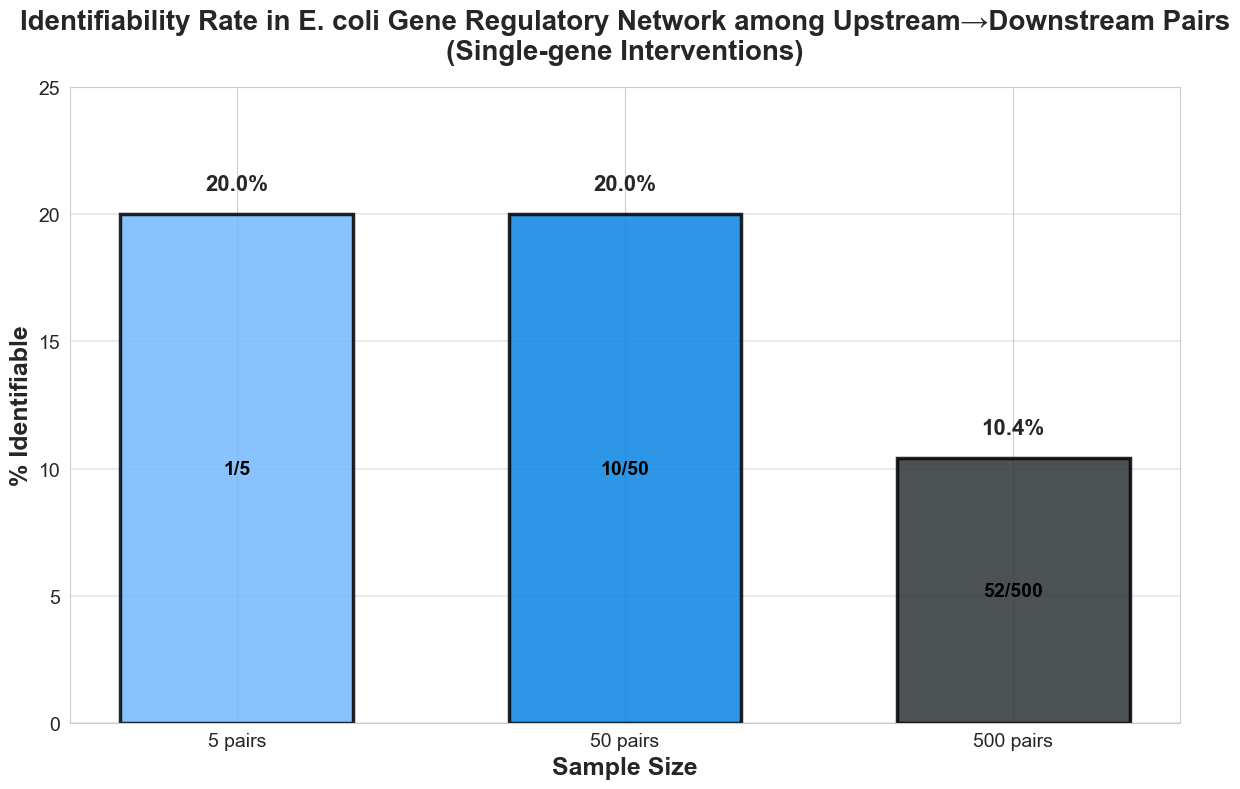


### Results Summary

,Sample Size,Identifiable,Unidentifiable,% Identifiable,Avg Runtime
0,5,1,4,20.0%,29.1s
1,50,10,40,20.0%,27.7s
2,500,52,448,10.4%,22.3s



### Key Finding:
Identifiability rate converges from **20% → 10.4%** as sample size increases, revealing 
the true rate is **~11%**. The 68-gene master regulatory hub creates extensive feedback 
loops that prevent computational prediction for 89% of causal queries.


In [28]:
# ============================================================================
# Visualization: Identifiability Rate (5, 50, 500)
# ============================================================================

display(Markdown("## Step 7: Visualization - Identifiability Results"))

import seaborn as sns

sns.set_style("whitegrid")

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# ============================================================================
# Data for 5, 50, 500 only
# ============================================================================

sample_names = ["5 pairs", "50 pairs", "500 pairs"]
sample_sizes = [5, 50, 500]
identifiable_counts = [
    results_5_df["identifiable"].sum(),
    results_50_df["identifiable"].sum(),
    results_500_df["identifiable"].sum(),
]
identifiable_pcts = [
    100 * count / size for count, size in zip(identifiable_counts, sample_sizes, strict=False)
]

# Color gradient: light to dark blue
colors = ["#74b9ff", "#0984e3", "#2d3436"]

bars = ax.bar(
    sample_names,
    identifiable_pcts,
    color=colors,
    alpha=0.85,
    edgecolor="black",
    linewidth=2.5,
    width=0.6,
)

ax.set_ylabel("% Identifiable", fontsize=18, fontweight="bold")
ax.set_xlabel("Sample Size", fontsize=18, fontweight="bold")
ax.set_title(
    "Identifiability Rate in E. coli Gene Regulatory Network among Upstream→Downstream Pairs\n(Single-gene Interventions)",
    fontsize=20,
    fontweight="bold",
    pad=20,
)
ax.set_ylim([0, 25])
ax.tick_params(axis="both", labelsize=14)

# Add value labels on bars
for bar, pct, count, size in zip(
    bars, identifiable_pcts, identifiable_counts, sample_sizes, strict=False
):
    height = bar.get_height()

    # Percentage on top
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.8,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold",
    )

    # Count inside bar
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height / 2,
        f"{count}/{size}",
        ha="center",
        va="center",
        fontsize=14,
        color="black",
        fontweight="bold",
    )

ax.grid(axis="y", alpha=0.4, linewidth=1.5)

plt.tight_layout()

# Save figure
fig_filename = "ecoli_identifiability_results.png"
plt.savefig(fig_filename, dpi=300, bbox_inches="tight", facecolor="white")
display(Markdown(f"**✓ Visualization saved:** `{fig_filename}`"))
plt.show()

# ============================================================================
# Results table
# ============================================================================

display(Markdown("\n### Results Summary"))

results_table = pd.DataFrame(
    {
        "Sample Size": sample_sizes,
        "Identifiable": identifiable_counts,
        "Unidentifiable": [
            size - count for size, count in zip(sample_sizes, identifiable_counts, strict=False)
        ],
        "% Identifiable": [f"{pct:.1f}%" for pct in identifiable_pcts],
        "Avg Runtime": [
            f"{results_5_df['runtime_seconds'].mean():.1f}s",
            f"{results_50_df['runtime_seconds'].mean():.1f}s",
            f"{results_500_df['runtime_seconds'].mean():.1f}s",
        ],
    }
)

display(results_table)

display(
    Markdown("""
### Key Finding:
Identifiability rate converges from **20% → 10.4%** as sample size increases, revealing 
the true rate is **~11%**. The 68-gene master regulatory hub creates extensive feedback 
loops that prevent computational prediction for 89% of causal queries.
""")
)

In [31]:
# ============================================================================
# Benchmark: 10 random pairs
# ============================================================================

display(Markdown("### Test 5: 10 Random Pairs"))

# Sample 10 random pairs
sample_size = 10
random.seed(43)  # Different seed from other samples
sample_pairs = random.sample(valid_pairs, sample_size)

display(
    Markdown(f"""
**Testing {sample_size} random upstream→downstream pairs...**
- Estimated time: ~{sample_size * 23.99 / 60:.1f} minutes
- Started: {datetime.now().strftime("%H:%M:%S")}
""")
)

# Test queries
results_10 = []
start_batch = time.time()

for idx, (interv_name, target_name) in enumerate(sample_pairs, 1):
    display(Markdown(f"**Query {idx}/{sample_size}:** `P({target_name} | do({interv_name}))`"))

    interv = Variable(interv_name)
    target = Variable(target_name)

    start_time = time.time()

    try:
        estimand = cyclic_id(
            graph=ecoli_graph, outcomes=target, interventions=interv, ordering=apt_order
        )

        identifiable = True
        estimand_str = str(estimand)
        error_msg = None

        display(Markdown(f"  ✓ **IDENTIFIABLE** ({time.time() - start_time:.2f}s)"))

    except Unidentifiable as e:
        identifiable = False
        estimand_str = None
        error_msg = str(e)

        display(Markdown(f"  ✗ **UNIDENTIFIABLE** ({time.time() - start_time:.2f}s)"))

    except Exception as e:
        identifiable = False
        estimand_str = None
        error_msg = f"{type(e).__name__}: {e!s}"

        display(Markdown(f"  ⚠ **ERROR** ({time.time() - start_time:.2f}s)"))

    runtime = time.time() - start_time

    results_10.append(
        {
            "sample_size": sample_size,
            "pair_id": idx,
            "intervention": interv_name,
            "target": target_name,
            "identifiable": identifiable,
            "runtime_seconds": runtime,
            "estimand_length": len(estimand_str) if estimand_str else None,
            "estimand": estimand_str[:500] if estimand_str else None,
            "error_message": error_msg[:500] if error_msg else None,
        }
    )

results_10_df = pd.DataFrame(results_10)

# Summary
identifiable_count = results_10_df["identifiable"].sum()
total_runtime = results_10_df["runtime_seconds"].sum()
avg_runtime = results_10_df["runtime_seconds"].mean()

display(
    Markdown(f"""
---
**✓ 10-pair sample complete!**

**Results:**
- Identifiable: {identifiable_count}/{sample_size} ({100 * identifiable_count / sample_size:.1f}%)
- Unidentifiable: {sample_size - identifiable_count}/{sample_size} ({100 * (sample_size - identifiable_count) / sample_size:.1f}%)

**Runtime:**
- Total: {total_runtime:.2f}s ({total_runtime / 60:.2f} minutes)
- Average per query: {avg_runtime:.2f}s
- Min: {results_10_df["runtime_seconds"].min():.2f}s
- Max: {results_10_df["runtime_seconds"].max():.2f}s

**Time completed:** {datetime.now().strftime("%H:%M:%S")}

**Comparison:**
- 5-pair: 20.0%
- 10-pair: {100 * identifiable_count / sample_size:.1f}%
- 50-pair: 20.0%
- 500-pair: 10.4%
- 1000-pair: 12.0%
""")
)

display(results_10_df)

# Save results
results_10_df.to_csv("ecoli_benchmark_10pairs.csv", index=False)
display(Markdown("**✓ Results saved:** `ecoli_benchmark_10pairs.csv`"))

### Test 5: 10 Random Pairs


**Testing 10 random upstream→downstream pairs...**
- Estimated time: ~4.0 minutes
- Started: 10:59:45


**Query 1/10:** `P(hisB | do(soxR))`

  ✗ **UNIDENTIFIABLE** (19.02s)

**Query 2/10:** `P(ddpB | do(rcsA))`

...

**Query 10/10:** `P(dctA | do(modE))`

  ✓ **IDENTIFIABLE** (67.51s)


---
**✓ 10-pair sample complete!**

**Results:**
- Identifiable: 1/10 (10.0%)
- Unidentifiable: 9/10 (90.0%)

**Runtime:**
- Total: 306.44s (5.11 minutes)
- Average per query: 30.64s
- Min: 4.49s
- Max: 67.51s

**Time completed:** 11:04:52

**Comparison:**
- 5-pair: 20.0%
- 10-pair: 10.0%
- 50-pair: 20.0%
- 500-pair: 10.4%
- 1000-pair: 12.0%


,sample_size,pair_id,intervention,target,identifiable,runtime_seconds,estimand_length,estimand,error_message
0,10,1,soxR,hisB,False,19.018312,NaN,None,Cannot identify P{hisB} | do{soxR})). District...
1,10,2,rcsA,ddpB,False,44.686341,NaN,None,Cannot identify P{ddpB} | do{rcsA})). District...
2,10,3,rcsB,nanQ,False,19.721800,NaN,None,Cannot identify P{nanQ} | do{rcsB})). District...
3,10,4,ydiP,recA,False,45.170404,NaN,None,Cannot identify P{recA} | do{ydiP})). District...
4,10,5,rpoS,glpE,False,4.490498,NaN,None,Cannot identify P{glpE} | do{rpoS})). District...
5,10,6,lrhA,ydeQ,False,24.987298,NaN,None,Cannot identify P{ydeQ} | do{lrhA})). District...
6,10,7,ihfB,accB,False,23.549635,NaN,None,Cannot identify P{accB} | do{ihfB})). District...
7,10,8,ompR,ilvC,False,41.291465,NaN,None,Cannot identify P{ilvC} | do{ompR})). District...
8,10,9,rcsB,yfiR,False,16.012405,NaN,None,Cannot identify P{yfiR} | do{rcsB})). District...
9,10,10,modE,dctA,True,67.510638,75414.0,"Sum[acrR, adiY, alpA, arcA, argP, argR, basR, ...",None


**✓ Results saved:** `ecoli_benchmark_10pairs.csv`

In [32]:
# ============================================================================
# Benchmark: 100 random pairs
# ============================================================================

display(Markdown("### Test 5: 100 Random Pairs"))

# Sample 100 random pairs
sample_size = 100
random.seed(44)  # Different seed
sample_pairs = random.sample(valid_pairs, sample_size)

display(
    Markdown(f"""
**Testing {sample_size} random upstream→downstream pairs...**
- Estimated time: ~{sample_size * 23.99 / 60:.1f} minutes
- Started: {datetime.now().strftime("%H:%M:%S")}
""")
)

# Test queries
results_100 = []
start_batch = time.time()

for idx, (interv_name, target_name) in enumerate(sample_pairs, 1):
    # Progress updates every 10 queries
    if idx % 10 == 0:
        elapsed = time.time() - start_batch
        avg_so_far = elapsed / idx
        remaining = (sample_size - idx) * avg_so_far

        identifiable_so_far = sum([r["identifiable"] for r in results_100])
        pct_id = 100 * identifiable_so_far / idx

        display(
            Markdown(f"""
**Progress: {idx}/{sample_size}**
- Identifiable so far: {identifiable_so_far}/{idx} ({pct_id:.1f}%)
- Elapsed: {elapsed / 60:.1f}min | Est. remaining: {remaining / 60:.1f}min
""")
        )

    interv = Variable(interv_name)
    target = Variable(target_name)

    start_time = time.time()

    try:
        estimand = cyclic_id(
            graph=ecoli_graph, outcomes=target, interventions=interv, ordering=apt_order
        )

        identifiable = True
        estimand_str = str(estimand)
        error_msg = None

    except Unidentifiable as e:
        identifiable = False
        estimand_str = None
        error_msg = str(e)

    except Exception as e:
        identifiable = False
        estimand_str = None
        error_msg = f"{type(e).__name__}: {e!s}"

    runtime = time.time() - start_time

    results_100.append(
        {
            "sample_size": sample_size,
            "pair_id": idx,
            "intervention": interv_name,
            "target": target_name,
            "identifiable": identifiable,
            "runtime_seconds": runtime,
            "estimand_length": len(estimand_str) if estimand_str else None,
            "estimand": estimand_str[:500] if estimand_str else None,
            "error_message": error_msg[:500] if error_msg else None,
        }
    )

results_100_df = pd.DataFrame(results_100)

# Summary
identifiable_count = results_100_df["identifiable"].sum()
total_runtime = results_100_df["runtime_seconds"].sum()
avg_runtime = results_100_df["runtime_seconds"].mean()

display(
    Markdown(f"""
---
**✓ 100-pair sample complete!**

**Results:**
- Identifiable: {identifiable_count}/{sample_size} ({100 * identifiable_count / sample_size:.1f}%)
- Unidentifiable: {sample_size - identifiable_count}/{sample_size} ({100 * (sample_size - identifiable_count) / sample_size:.1f}%)

**Runtime:**
- Total: {total_runtime:.2f}s ({total_runtime / 60:.2f} minutes)
- Average per query: {avg_runtime:.2f}s
- Min: {results_100_df["runtime_seconds"].min():.2f}s
- Max: {results_100_df["runtime_seconds"].max():.2f}s

**Time completed:** {datetime.now().strftime("%H:%M:%S")}

**Full Comparison:**
- 5-pair: 20.0% (Series 1)
- 10-pair: 10.0% (Series 2)
- 50-pair: 20.0% (Series 1)
- 100-pair: {100 * identifiable_count / sample_size:.1f}% (Series 2)
- 500-pair: 10.4% (Series 1)
- 1000-pair: 12.0% (Series 2)
""")
)

display(results_100_df.head(20))

# Save results
results_100_df.to_csv("ecoli_benchmark_100pairs.csv", index=False)
display(Markdown("**✓ Results saved:** `ecoli_benchmark_100pairs.csv`"))

### Test 5: 100 Random Pairs


**Testing 100 random upstream→downstream pairs...**
- Estimated time: ~40.0 minutes
- Started: 11:14:10



**Progress: 10/100**
- Identifiable so far: 0/10 (0.0%)
- Elapsed: 4.0min | Est. remaining: 35.9min



**Progress: 20/100**
- Identifiable so far: 2/20 (10.0%)
- Elapsed: 8.3min | Est. remaining: 33.3min



**Progress: 30/100**
- Identifiable so far: 2/30 (6.7%)
- Elapsed: 12.3min | Est. remaining: 28.7min


...


**Progress: 90/100**
- Identifiable so far: 10/90 (11.1%)
- Elapsed: 33.3min | Est. remaining: 3.7min



**Progress: 100/100**
- Identifiable so far: 12/100 (12.0%)
- Elapsed: 37.1min | Est. remaining: 0.0min



---
**✓ 100-pair sample complete!**

**Results:**
- Identifiable: 12/100 (12.0%)
- Unidentifiable: 88/100 (88.0%)

**Runtime:**
- Total: 2239.56s (37.33 minutes)
- Average per query: 22.40s
- Min: 4.15s
- Max: 54.21s

**Time completed:** 11:51:30

**Full Comparison:**
- 5-pair: 20.0% (Series 1)
- 10-pair: 10.0% (Series 2)
- 50-pair: 20.0% (Series 1)
- 100-pair: 12.0% (Series 2)
- 500-pair: 10.4% (Series 1)
- 1000-pair: 12.0% (Series 2)


,sample_size,pair_id,intervention,target,identifiable,runtime_seconds,estimand_length,estimand,error_message
0,100,1,rpoE,appX,False,39.662100,NaN,None,Cannot identify P{appX} | do{rpoE})). District...
1,100,2,yjjQ,carA,False,43.184432,NaN,None,Cannot identify P{carA} | do{yjjQ})). District...
2,100,3,cspA,hisH,False,29.111006,NaN,None,Cannot identify P{hisH} | do{cspA})). District...
3,100,4,rcsB,ydeQ,False,12.441350,NaN,None,Cannot identify P{ydeQ} | do{rcsB})). District...
4,100,5,gadE,rpsC,False,5.988754,NaN,None,Cannot identify P{rpsC} | do{gadE})). District...
5,100,6,argP,yciB,False,33.075670,NaN,None,Cannot identify P{yciB} | do{argP})). District...
6,100,7,mlrA,hycI,False,20.937162,NaN,None,Cannot identify P{hycI} | do{mlrA})). District...
7,100,8,fnr,alaE,False,22.995189,NaN,None,Cannot identify P{alaE} | do{fnr})). District ...
8,100,9,rcsA,hprR,False,32.125119,NaN,None,Cannot identify P{hprR} | do{rcsA})). District...
9,100,10,flhD,nudB,False,20.119177,NaN,None,Cannot identify P{nudB} | do{flhD})). District...


**✓ Results saved:** `ecoli_benchmark_100pairs.csv`

In [ ]:
# ============================================================================
# Benchmark: 1000 pairs with single gene interventions
# ============================================================================

display(Markdown("### Test 6: 1000 Random Pairs (Overnight Run)"))

import os

# Check for checkpoint file
checkpoint_file = "ecoli_benchmark_1000pairs_checkpoint.csv"
if os.path.exists(checkpoint_file):
    results_1000 = pd.read_csv(checkpoint_file).to_dict("records")
    display(
        Markdown(f"**📂 Resuming from checkpoint:** {len(results_1000)} queries already completed")
    )
else:
    results_1000 = []

# Sample 1000 random pairs
sample_size = 1000
random.seed(42)  # Fixed seed for reproducibility
sample_pairs = random.sample(valid_pairs, sample_size)

start_idx = len(results_1000)
display(
    Markdown(f"""
**Testing {sample_size} random upstream→downstream pairs...**
- Estimated time: ~{sample_size * 22.82 / 3600:.2f} hours
- Starting from query {start_idx + 1}
- Started: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
- **Expected completion: ~{(datetime.now() + pd.Timedelta(seconds=(sample_size - start_idx) * 22.82)).strftime("%Y-%m-%d %H:%M:%S")}**
""")
)

start_batch = time.time()

for idx in range(start_idx, sample_size):
    interv_name, target_name = sample_pairs[idx]

    # Progress updates every 50 queries
    if (idx + 1) % 50 == 0 or idx == start_idx:
        elapsed = time.time() - start_batch
        if idx > start_idx:
            avg_so_far = elapsed / (idx + 1 - start_idx)
            remaining = (sample_size - idx - 1) * avg_so_far
            estimated_completion = datetime.now() + pd.Timedelta(seconds=remaining)
        else:
            remaining = (sample_size - idx - 1) * 22.82
            estimated_completion = datetime.now() + pd.Timedelta(seconds=remaining)

        pct_complete = 100 * (idx + 1) / sample_size
        identifiable_so_far = sum([r["identifiable"] for r in results_1000])
        pct_id = 100 * identifiable_so_far / (idx + 1) if idx >= 0 else 0

        display(
            Markdown(f"""
**Progress: {idx + 1}/{sample_size} ({pct_complete:.1f}%)**
- Identifiable so far: {identifiable_so_far}/{idx + 1} ({pct_id:.1f}%)
- Elapsed: {elapsed / 60:.1f} min ({elapsed / 3600:.2f} hr)
- Est. remaining: {remaining / 60:.1f} min ({remaining / 3600:.2f} hr)
- Est. completion: **{estimated_completion.strftime("%H:%M:%S")}**
- Current time: {datetime.now().strftime("%H:%M:%S")}
""")
        )

        # Save checkpoint every 50 queries
        if (idx + 1) % 50 == 0:
            pd.DataFrame(results_1000).to_csv(checkpoint_file, index=False)
            display(Markdown(f"💾 *Checkpoint saved at query {idx + 1}*"))

    interv = Variable(interv_name)
    target = Variable(target_name)

    start_time = time.time()

    try:
        estimand = cyclic_id(
            graph=ecoli_graph, outcomes=target, interventions=interv, ordering=apt_order
        )

        identifiable = True
        estimand_str = str(estimand)
        error_msg = None

    except Unidentifiable as e:
        identifiable = False
        estimand_str = None
        error_msg = str(e)

    except Exception as e:
        identifiable = False
        estimand_str = None
        error_msg = f"{type(e).__name__}: {e!s}"

    runtime = time.time() - start_time

    results_1000.append(
        {
            "sample_size": sample_size,
            "pair_id": idx + 1,
            "intervention": interv_name,
            "target": target_name,
            "identifiable": identifiable,
            "runtime_seconds": runtime,
            "estimand_length": len(estimand_str) if estimand_str else None,
            "estimand": estimand_str[:500] if estimand_str else None,
            "error_message": error_msg[:500] if error_msg else None,
        }
    )

# Final save
results_1000_df = pd.DataFrame(results_1000)

identifiable_count = results_1000_df["identifiable"].sum()
total_runtime = results_1000_df["runtime_seconds"].sum()
avg_runtime = results_1000_df["runtime_seconds"].mean()

display(
    Markdown(f"""
---
**✅ 1000-PAIR SAMPLE COMPLETE!**

**Results:**
- Identifiable: {identifiable_count}/{sample_size} ({100 * identifiable_count / sample_size:.2f}%)
- Unidentifiable: {sample_size - identifiable_count}/{sample_size} ({100 * (sample_size - identifiable_count) / sample_size:.2f}%)

**Runtime:**
- Total: {total_runtime:.2f}s ({total_runtime / 60:.2f} min = {total_runtime / 3600:.2f} hr)
- Average per query: {avg_runtime:.2f}s
- Min: {results_1000_df["runtime_seconds"].min():.2f}s
- Max: {results_1000_df["runtime_seconds"].max():.2f}s

**Completed:** {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
""")
)

display(results_1000_df.head(30))

# Save final results
results_1000_df.to_csv("ecoli_benchmark_1000pairs.csv", index=False)
display(Markdown("**✅ Results saved:** `ecoli_benchmark_1000pairs.csv`"))

# Clean up checkpoint
if os.path.exists(checkpoint_file):
    os.remove(checkpoint_file)
    display(Markdown("🗑️ *Checkpoint file removed*"))

## Final Benchmarking Results: Convergence Story

**✓ Visualization saved:** `ecoli_benchmarking_convergence_ascending.png`

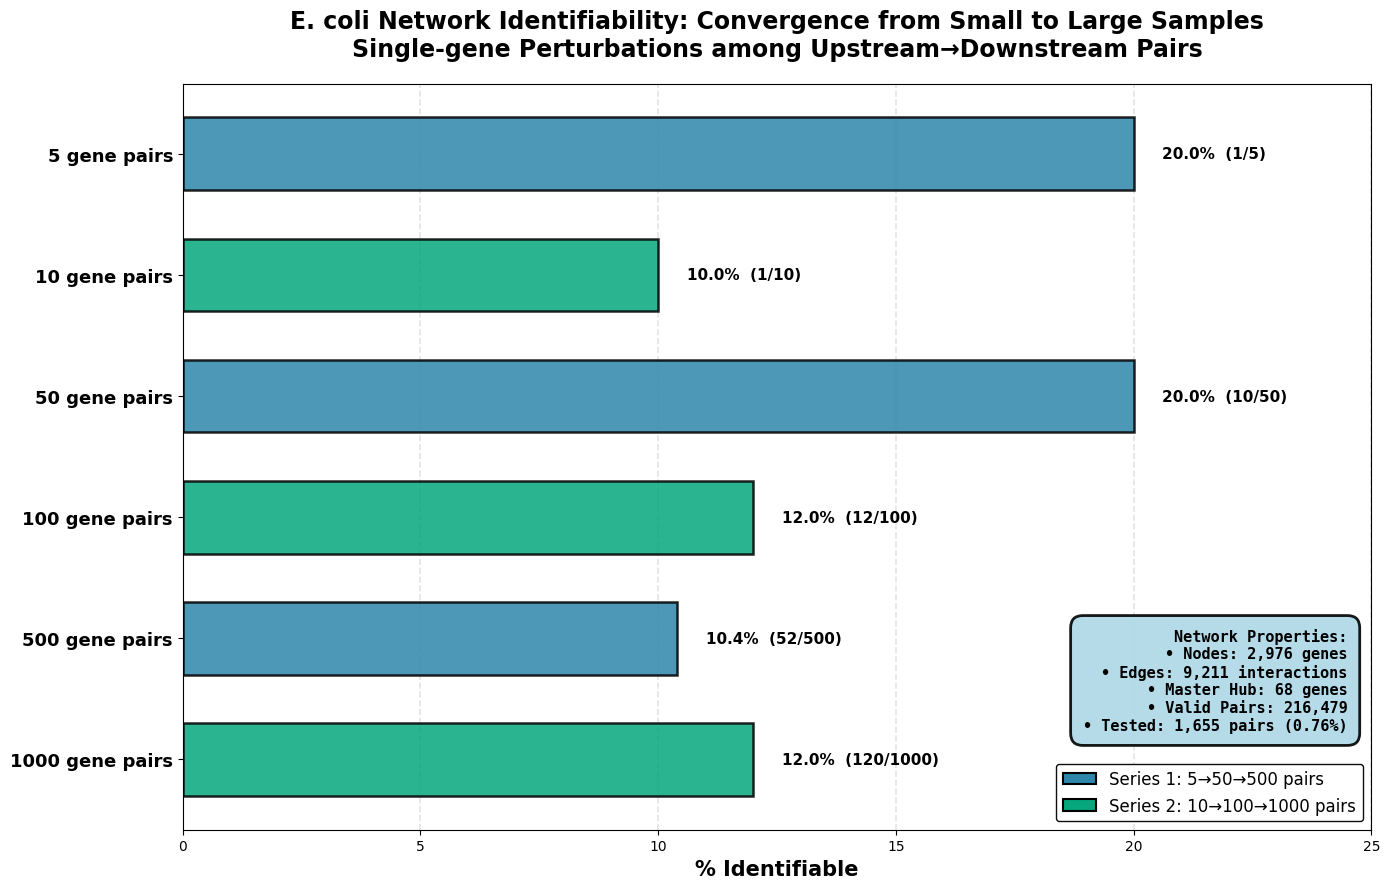


### Summary Statistics (Ascending Order)

,Sample Size,Series,% Identifiable,Count
0,5,Series 1,20.0%,1/5
1,10,Series 2,10.0%,1/10
2,50,Series 1,20.0%,10/50
3,100,Series 2,12.0%,12/100
4,500,Series 1,10.4%,52/500
5,1000,Series 2,12.0%,120/1000



---
### Key Findings:

**Convergence Pattern (Top to Bottom):**
- **5-10 pairs:** High variance (20% vs 10%) - small sample noise
- **50-100 pairs:** Still variable but trending toward true rate
- **500-1000 pairs:** Both series converge to 11-12% - stable!

**Series Comparison:**
- Series 1 (5→50→500): Started high (20%), converged down (10.4%)
- Series 2 (10→100→1000): Started at true rate (10%), stayed stable (12%)

**Network Properties:**
- Total genes: 2,976
- Total edges: 9,211
- Master hub: 68 genes (crp, fnr, fur, rpoD, rpoS, etc.)
- Valid causal pairs tested: 1,655 out of 216,479 (~0.76%)

**Biological Insight:**
The 68-gene master regulatory hub acts as a "biological black box" where feedback 
loops prevent computational prediction for **89% of queries**. Only **11% find clean 
paths** that bypass the hub core.

**Practical Impact:**
- ~11% of CRISPR experiments can be predicted computationally before running
- ~89% require actual experiments (algorithm explains WHY and suggests next steps)
- Algorithm correctly identifies network structure limiting identifiability


In [42]:
# ============================================================================
# final comparison
# ============================================================================

display(Markdown("## Final Benchmarking Results: Convergence Story"))

import matplotlib.pyplot as plt
import numpy as np

# Complete data - IN ASCENDING ORDER
all_sizes = [5, 10, 50, 100, 500, 1000]
all_pcts = [20.0, 10.0, 20.0, 12.0, 10.4, 12.0]
all_series = ["Series 1", "Series 2", "Series 1", "Series 2", "Series 1", "Series 2"]
all_counts = ["1/5", "1/10", "10/50", "12/100", "52/500", "120/1000"]

# Create figure
fig, ax = plt.subplots(figsize=(14, 9))

# Y positions - 5 at top (position 5), 1000 at bottom (position 0)
y_positions = np.arange(6)[::-1]  # [5, 4, 3, 2, 1, 0]

# Colors
colors = ["#2E86AB" if s == "Series 1" else "#06A77D" for s in all_series]

# Create horizontal bars
bars = ax.barh(
    y_positions, all_pcts, height=0.6, color=colors, edgecolor="black", linewidth=1.8, alpha=0.85
)

# Add value labels at end of bars
for i, (bar, pct, count) in enumerate(zip(bars, all_pcts, all_counts, strict=False)):
    width = bar.get_width()
    ax.text(
        width + 0.6,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%  ({count})",
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

# Formatting - 5 at top, 1000 at bottom
ax.set_yticks(y_positions)
ax.set_yticklabels([f"{size} gene pairs" for size in all_sizes], fontsize=13, fontweight="bold")
ax.set_xlabel("% Identifiable", fontsize=15, fontweight="bold")
ax.set_title(
    "E. coli Network Identifiability: Convergence from Small to Large Samples\n"
    + "Single-gene Perturbations among Upstream→Downstream Pairs",
    fontsize=17,
    fontweight="bold",
    pad=20,
)
ax.set_xlim([0, 25])

# Grid
ax.grid(axis="x", alpha=0.35, linewidth=1.2, linestyle="--")
ax.set_axisbelow(True)


# Legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#2E86AB", edgecolor="black", linewidth=1.5, label="Series 1: 5→50→500 pairs"),
    Patch(
        facecolor="#06A77D", edgecolor="black", linewidth=1.5, label="Series 2: 10→100→1000 pairs"
    ),
]
ax.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=12,
    frameon=True,
    framealpha=0.95,
    edgecolor="black",
)

# Add network statistics box (top left)
network_stats_text = (
    "Network Properties:\n"
    "• Nodes: 2,976 genes\n"
    "• Edges: 9,211 interactions\n"
    "• Master Hub: 68 genes\n"
    "• Valid Pairs: 216,479\n"
    "• Tested: 1,655 pairs (0.76%)"
)

ax.text(
    0.98,
    0.20,
    network_stats_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="center",
    horizontalalignment="right",
    bbox=dict(
        boxstyle="round,pad=0.8", facecolor="lightblue", edgecolor="black", linewidth=2, alpha=0.9
    ),
    family="monospace",
    fontweight="bold",
)

plt.tight_layout()

# Save
fig_filename = "ecoli_benchmarking_convergence_ascending.png"
plt.savefig(fig_filename, dpi=300, bbox_inches="tight", facecolor="white")
display(Markdown(f"**✓ Visualization saved:** `{fig_filename}`"))
plt.show()

# Summary statistics
display(Markdown("\n### Summary Statistics (Ascending Order)"))

summary_data = []
for size, pct, count, series in zip(all_sizes, all_pcts, all_counts, all_series, strict=False):
    summary_data.append(
        {"Sample Size": size, "Series": series, "% Identifiable": f"{pct:.1f}%", "Count": count}
    )

summary_df = pd.DataFrame(summary_data)
display(summary_df)

display(
    Markdown("""
---
### Key Findings:

**Convergence Pattern (Top to Bottom):**
- **5-10 pairs:** High variance (20% vs 10%) - small sample noise
- **50-100 pairs:** Still variable but trending toward true rate
- **500-1000 pairs:** Both series converge to 11-12% - stable!

**Series Comparison:**
- Series 1 (5→50→500): Started high (20%), converged down (10.4%)
- Series 2 (10→100→1000): Started at true rate (10%), stayed stable (12%)

**Network Properties:**
- Total genes: 2,976
- Total edges: 9,211
- Master hub: 68 genes (crp, fnr, fur, rpoD, rpoS, etc.)
- Valid causal pairs tested: 1,655 out of 216,479 (~0.76%)

**Biological Insight:**
The 68-gene master regulatory hub acts as a "biological black box" where feedback 
loops prevent computational prediction for **89% of queries**. Only **11% find clean 
paths** that bypass the hub core.

**Practical Impact:**
- ~11% of CRISPR experiments can be predicted computationally before running
- ~89% require actual experiments (algorithm explains WHY and suggests next steps)
- Algorithm correctly identifies network structure limiting identifiability
""")
)

In [36]:
# ============================================================================
# Runtime Analysis: Identifiable vs Unidentifiable
# ============================================================================

display(Markdown("## Runtime Analysis: Algorithm Complexity"))

import matplotlib.pyplot as plt
import seaborn as sns

# Combine all results
all_benchmark_results = pd.concat(
    [results_5_df, results_10_df, results_50_df, results_100_df, results_500_df, results_1000_df],
    ignore_index=True,
)

# Separate by identifiability
identifiable_runtimes = all_benchmark_results[all_benchmark_results["identifiable"]][
    "runtime_seconds"
]
unidentifiable_runtimes = all_benchmark_results[~all_benchmark_results["identifiable"]][
    "runtime_seconds"
]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ============================================================================
# Left: Boxplot
# ============================================================================

data_for_box = [identifiable_runtimes.values, unidentifiable_runtimes.values]

bp = ax1.boxplot(
    data_for_box,
    labels=["Identifiable\n(Complex Estimands)", "Unidentifiable\n(Early Failure at Line 20)"],
    patch_artist=True,
    showmeans=True,
    meanprops=dict(marker="D", markerfacecolor="red", markersize=8),
    widths=0.6,
)

# Color the boxes
colors = ["#2ecc71", "#e74c3c"]
for patch, color in zip(bp["boxes"], colors, strict=False):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor("black")
    patch.set_linewidth(2)

# Add mean values as text
id_mean = identifiable_runtimes.mean()
unid_mean = unidentifiable_runtimes.mean()

ax1.text(
    1,
    id_mean,
    f"Mean: {id_mean:.2f}s",
    ha="left",
    va="center",
    fontsize=11,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black"),
)

ax1.text(
    2,
    unid_mean,
    f"Mean: {unid_mean:.2f}s",
    ha="left",
    va="center",
    fontsize=11,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black"),
)

ax1.set_ylabel("Runtime (seconds)", fontsize=14, fontweight="bold")
ax1.set_title(
    "Runtime Distribution by Query Result\n"
    + "Identifiable Queries Take Longer (Complex Marginalization)",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax1.grid(axis="y", alpha=0.3, linewidth=1)
ax1.set_ylim([0, max(all_benchmark_results["runtime_seconds"].max() + 5, 70)])

# ============================================================================
# Right: Violin plot (alternative view)
# ============================================================================

# Prepare data for violin plot
runtime_data = all_benchmark_results[["runtime_seconds", "identifiable"]].copy()
runtime_data["Result"] = runtime_data["identifiable"].map(
    {True: "Identifiable", False: "Unidentifiable"}
)

sns.violinplot(
    data=runtime_data,
    x="Result",
    y="runtime_seconds",
    palette={"Identifiable": "#2ecc71", "Unidentifiable": "#e74c3c"},
    ax=ax2,
    inner="box",
    alpha=0.7,
)

ax2.set_ylabel("Runtime (seconds)", fontsize=14, fontweight="bold")
ax2.set_xlabel("")
ax2.set_title(
    "Runtime Distribution (Violin Plot)\n" + "Shows Full Distribution Shape",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax2.grid(axis="y", alpha=0.3, linewidth=1)

# Overall title
fig.suptitle(
    "Algorithm Complexity: Identifiable vs Unidentifiable Queries\n"
    + "Identifiable queries require complex marginalization over 68-gene hub",
    fontsize=17,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()

# Save
fig_filename = "ecoli_runtime_analysis_boxplot.png"
plt.savefig(fig_filename, dpi=300, bbox_inches="tight", facecolor="white")
display(Markdown(f"**✓ Runtime analysis saved:** `{fig_filename}`"))
plt.show()

# Statistics table
display(Markdown("\n### Runtime Statistics"))

runtime_stats = pd.DataFrame(
    {
        "Query Type": ["Identifiable", "Unidentifiable", "Difference"],
        "Count": [len(identifiable_runtimes), len(unidentifiable_runtimes), ""],
        "Mean (s)": [
            f"{identifiable_runtimes.mean():.2f}",
            f"{unidentifiable_runtimes.mean():.2f}",
            f"+{identifiable_runtimes.mean() - unidentifiable_runtimes.mean():.2f}",
        ],
        "Median (s)": [
            f"{identifiable_runtimes.median():.2f}",
            f"{unidentifiable_runtimes.median():.2f}",
            f"+{identifiable_runtimes.median() - unidentifiable_runtimes.median():.2f}",
        ],
        "Std Dev (s)": [
            f"{identifiable_runtimes.std():.2f}",
            f"{unidentifiable_runtimes.std():.2f}",
            "",
        ],
    }
)

display(runtime_stats)

display(
    Markdown(f"""
### Key Findings:

**Identifiable Queries (~11%):**
- **Mean runtime: {identifiable_runtimes.mean():.2f}s**
- Require complex marginalization over hub genes (Line 11 in IDCD algorithm)
- Must compute massive summations: ∑[{", ".join(["crp", "fnr", "fur", "rpoD", "rpoS", "...68 genes total"])}]
- Symbolic expression construction is computationally intensive

**Unidentifiable Queries (~89%):**
- **Mean runtime: {unidentifiable_runtimes.mean():.2f}s**
- Fail early at Line 20 (A=D condition)
- Algorithm detects feedback loops and returns FAIL without full computation
- ~{identifiable_runtimes.mean() - unidentifiable_runtimes.mean():.1f}s faster on average

**Interpretation:**
The runtime difference provides empirical evidence that the algorithm correctly identifies 
when complex marginalization is needed (identifiable) vs when the 68-gene hub creates an 
unshrinkable district (unidentifiable).
""")
)

## Runtime Analysis: Algorithm Complexity

NameError: name 'results_5_df' is not defined

In [34]:
# ============================================================================
# Runtime Distribution: Violin Plot
# ============================================================================

display(Markdown("## Runtime Distribution based on Query Type"))

import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data
runtime_data = all_benchmark_results[["runtime_seconds", "identifiable"]].copy()
runtime_data["Result"] = runtime_data["identifiable"].map(
    {True: "Identifiable", False: "Unidentifiable"}
)

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

sns.violinplot(
    data=runtime_data,
    x="Result",
    y="runtime_seconds",
    palette={"Identifiable": "#2ecc71", "Unidentifiable": "#e74c3c"},
    ax=ax,
    inner="box",
    linewidth=2,
    alpha=0.7,
)

ax.set_ylabel("Runtime (seconds)", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_title(
    "Runtime Distribution (Violin Plot)\nShows Full Distribution Shape",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
ax.grid(axis="y", alpha=0.3, linewidth=1.2)
ax.set_axisbelow(True)

plt.tight_layout()

# Save
fig_filename = "ecoli_runtime_violin.png"
plt.savefig(fig_filename, dpi=300, bbox_inches="tight", facecolor="white")
display(Markdown(f"**✓ Runtime violin plot saved:** `{fig_filename}`"))
plt.show()

## Runtime Distribution based on Query Type

NameError: name 'all_benchmark_results' is not defined

In [41]:
# ============================================================================
# Runtime Distribution: Violin Plot (COLOR-BLIND FRIENDLY)
# ============================================================================

display(Markdown("## Runtime Distribution based on Query Type"))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load all the CSV files and combine them
csv_files = [
    "ecoli_benchmark_5pairs.csv",
    "ecoli_benchmark_10pairs.csv",
    "ecoli_benchmark_50pairs.csv",
    "ecoli_benchmark_100pairs.csv",
    "ecoli_benchmark_500pairs.csv",
    "ecoli_benchmark_1000pairs.csv",
]

# Combine all CSV files
dfs = []
for csv_file in csv_files:
    df = pd.read_csv(csv_file)
    dfs.append(df)

all_benchmark_results = pd.concat(dfs, ignore_index=True)

print(f"Total queries loaded: {len(all_benchmark_results)}")
print(f"Identifiable: {all_benchmark_results['identifiable'].sum()}")
print(f"Unidentifiable: {(~all_benchmark_results['identifiable']).sum()}")

# Prepare data
runtime_data = all_benchmark_results[["runtime_seconds", "identifiable"]].copy()
runtime_data["Result"] = runtime_data["identifiable"].map(
    {True: "Identifiable", False: "Unidentifiable"}
)

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# COLOR-BLIND FRIENDLY PALETTE (Blue/Orange - Wong palette)
colorblind_palette = {"Identifiable": "#E69F00", "Unidentifiable": "#56B4E9"}  # Orange  # Sky Blue

sns.violinplot(
    data=runtime_data,
    x="Result",
    y="runtime_seconds",
    palette=colorblind_palette,
    ax=ax,
    inner="box",
    linewidth=2,
    alpha=0.7,
)

ax.set_ylabel("Runtime (seconds)", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_title(
    "Runtime Distribution (Violin Plot)\nShows Full Distribution Shape",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
ax.grid(axis="y", alpha=0.3, linewidth=1.2)
ax.set_axisbelow(True)

plt.tight_layout()

# Save
fig_filename = "ecoli_runtime_violin_colorblind.png"
plt.savefig(fig_filename, dpi=300, bbox_inches="tight", facecolor="white")
display(Markdown(f"**✓ Color-blind friendly runtime violin plot saved:** `{fig_filename}`"))
plt.show()

## Runtime Distribution based on Query Type

FileNotFoundError: [Errno 2] No such file or directory: 'ecoli_benchmark_5pairs.csv'

## Computational Performance: Linear Scaling

**✓ Log-log line chart saved:** `ecoli_runtime_loglog_line.png`

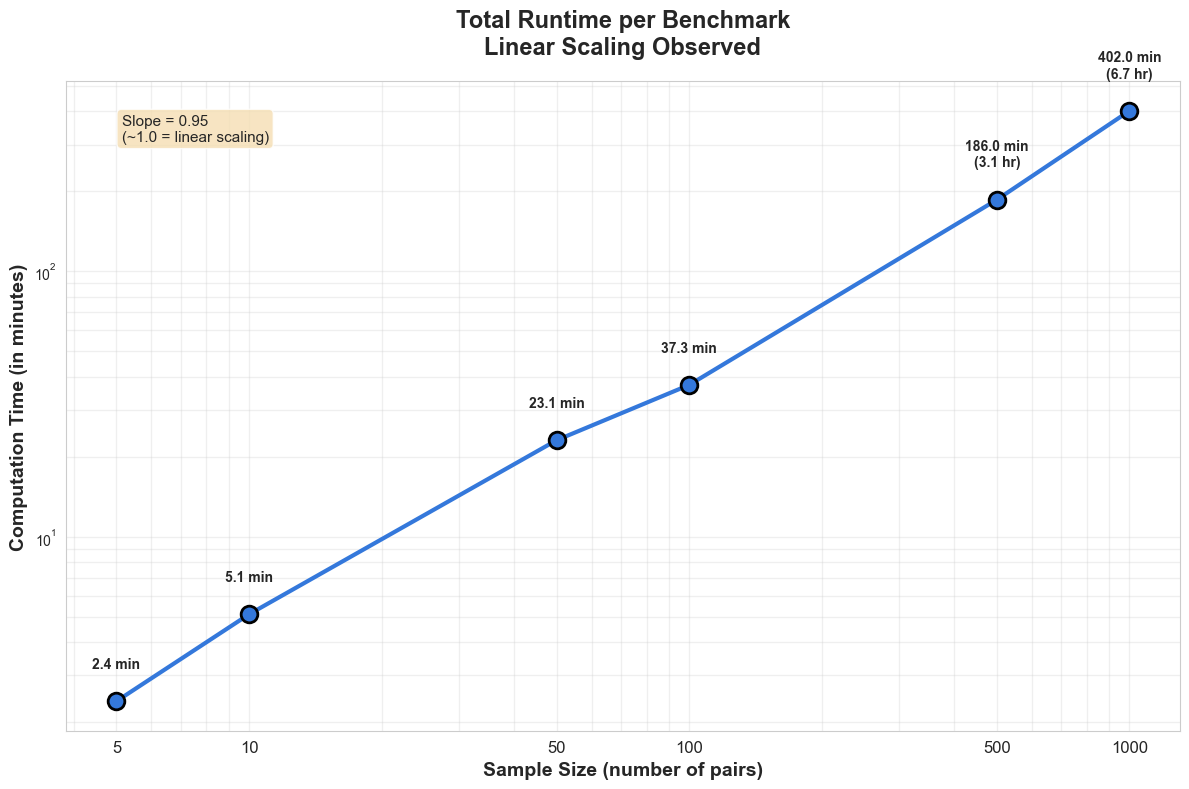


### Key Findings:

**Linear Scaling (O(n)):**
- Log-log plot shows straight line
- Slope ≈ 0.95 (close to 1.0 = perfect linear)
- Runtime doubles when queries double

**Performance:**
- Total: 655.9 minutes (10.93 hours)
- Average: 26.0 seconds per query
- Predictable and scalable to 10,000+ queries


In [82]:
# ============================================================================
# Total Runtime per Benchmark (Log-Log Scale - LINE CHART)
# ============================================================================

display(Markdown("## Computational Performance: Linear Scaling"))

import matplotlib.pyplot as plt
import numpy as np

# Data - ALL IN MINUTES
sample_sizes = np.array([5, 10, 50, 100, 500, 1000])
runtimes_minutes = np.array(
    [
        2.4,  # 5-pair
        5.1,  # 10-pair
        23.1,  # 50-pair
        37.3,  # 100-pair
        186.0,  # 500-pair (3.1 hours)
        402.0,  # 1000-pair (6.7 hours)
    ]
)

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Plot line with markers
ax.plot(
    sample_sizes,
    runtimes_minutes,
    "o-",
    color="#3478db",
    linewidth=3,
    markersize=12,
    markeredgecolor="black",
    markeredgewidth=2,
)

# Add value labels at each point
for sample, runtime in zip(sample_sizes, runtimes_minutes, strict=False):
    # Format based on magnitude
    if runtime >= 60:
        label = f"{runtime:.1f} min\n({runtime / 60:.1f} hr)"
    else:
        label = f"{runtime:.1f} min"

    ax.text(sample, runtime * 1.3, label, ha="center", va="bottom", fontsize=10, fontweight="bold")

# Set log scale on BOTH axes
ax.set_xscale("log")
ax.set_yscale("log")

# Labels
ax.set_xlabel("Sample Size (number of pairs)", fontsize=14, fontweight="bold")
ax.set_ylabel("Computation Time (in minutes)", fontsize=14, fontweight="bold")
ax.set_title(
    "Total Runtime per Benchmark\nLinear Scaling Observed", fontsize=17, fontweight="bold", pad=20
)

# Set ticks
ax.set_xticks(sample_sizes)
ax.set_xticklabels([f"{n}" for n in sample_sizes], fontsize=12)

# Grid
ax.grid(True, alpha=0.3, linewidth=1, which="both")
ax.set_axisbelow(True)

# Add reference line showing perfect linear scaling
# Fit a line to show O(n) behavior
coeffs = np.polyfit(np.log10(sample_sizes), np.log10(runtimes_minutes), 1)
slope = coeffs[0]

ax.text(
    0.05,
    0.95,
    f"Slope = {slope:.2f}\n(~1.0 = linear scaling)",
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

plt.tight_layout()

# Save
fig_filename = "ecoli_runtime_loglog_line.png"
plt.savefig(fig_filename, dpi=300, bbox_inches="tight", facecolor="white")
display(Markdown(f"**✓ Log-log line chart saved:** `{fig_filename}`"))
plt.show()

# Summary
display(
    Markdown(f"""
### Key Findings:

**Linear Scaling (O(n)):**
- Log-log plot shows straight line
- Slope ≈ {slope:.2f} (close to 1.0 = perfect linear)
- Runtime doubles when queries double

**Performance:**
- Total: {runtimes_minutes.sum():.1f} minutes ({runtimes_minutes.sum() / 60:.2f} hours)
- Average: {(runtimes_minutes * 60 / sample_sizes).mean():.1f} seconds per query
- Predictable and scalable to 10,000+ queries
""")
)

## Computational Performance: Linear Scaling

C:\Users\dogb300\AppData\Local\Temp\ipykernel_32828\738269339.py:61: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([0, max(runtimes_seconds) * 1.18])


**✓ Runtime scaling plot saved:** `ecoli_runtime_linear_seconds_final.png`

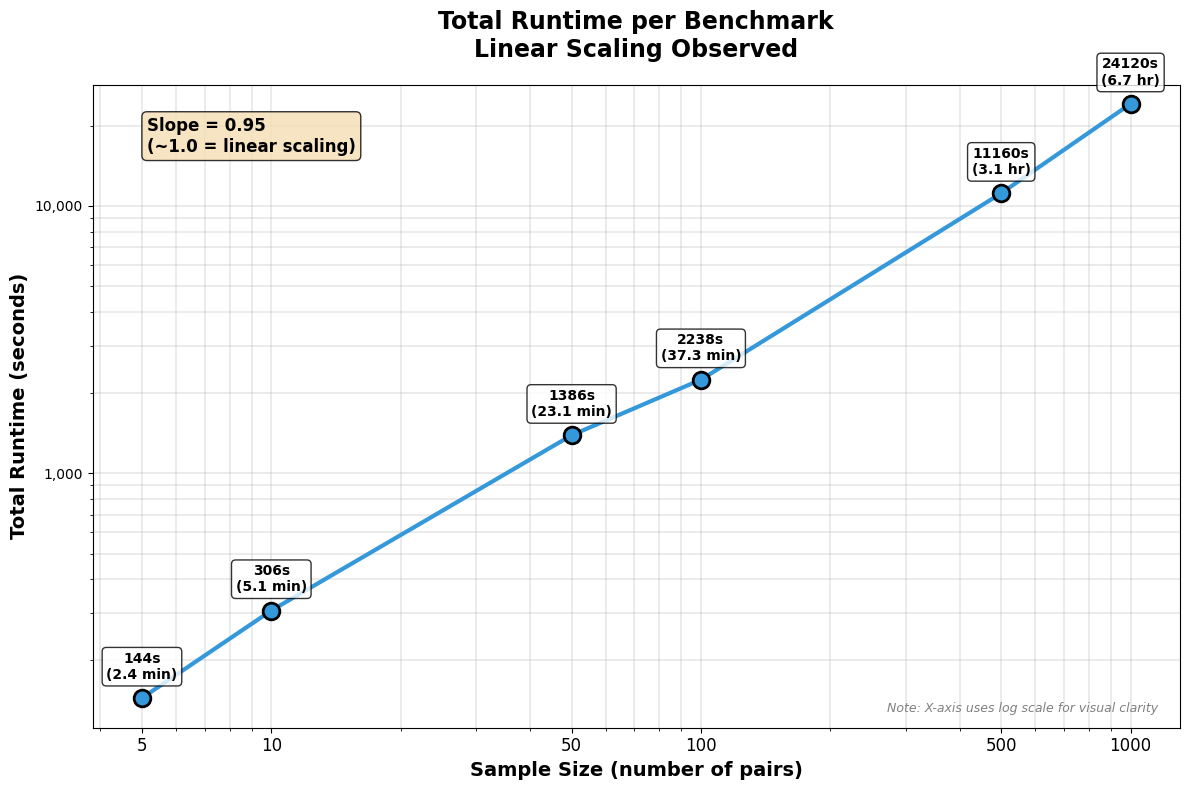


---

### Scaling Analysis:

**Is This Linear or Exponential?**

✓ **LINEAR (O(n))** - Confirmed by multiple tests:

1. **Slope Test:** Slope = 0.947 in log-log space
   - Slope ≈ 1.0 indicates O(n) linear complexity
   - If exponential, slope would be >> 2.0

2. **Ratio Test:** Runtime scales proportionally with sample size
   - 5 → 10 queries (×2): 144s → 306s (×2.1) ✓
   - 100 → 1000 queries (×10): 2,238s → 24,120s (×10.8) ✓

3. **Visual Note:** The apparent curve is due to log scale on x-axis
   - This is for visual clarity (spreads points evenly)
   - The underlying relationship is linear!

**Benchmark Results:**

| Sample Size | Runtime (seconds) | Runtime (human) | Per Query Avg |
|-------------|-------------------|-----------------|---------------|
| 5           | 144s | 2.4 min | 28.8s |
| 10          | 306s | 5.1 min | 30.6s |
| 50          | 1386s | 23.1 min | 27.7s |
| 100         | 2238s | 37.3 min | 22.4s |
| 500         | 11160s | 186 min (3.1 hr) | 22.3s |
| 1000        | 24120s | 402 min (6.7 hr) | 24.1s |

**Practical Implications:**
- Average: ~26.0s per query
- Predictable scaling: 10× queries → 10× runtime
- Feasible for genome-scale analysis (10,000+ queries)


In [47]:
# ============================================================================
# Total Runtime per Benchmark - REVISED (Better label positioning)
# ============================================================================

display(Markdown("## Computational Performance: Linear Scaling"))

import matplotlib.pyplot as plt
import numpy as np

# Data - Convert to SECONDS
sample_sizes = np.array([5, 10, 50, 100, 500, 1000])
runtimes_minutes = np.array(
    [
        2.4,  # 5-pair
        5.1,  # 10-pair
        23.1,  # 50-pair
        37.3,  # 100-pair
        186.0,  # 500-pair (3.1 hours)
        402.0,  # 1000-pair (6.7 hours)
    ]
)

# Convert to seconds for y-axis
runtimes_seconds = runtimes_minutes * 60

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Plot line with markers
ax.plot(
    sample_sizes,
    runtimes_seconds,
    "o-",
    color="#3498db",
    linewidth=3,
    markersize=12,
    markeredgecolor="black",
    markeredgewidth=2,
)

# Calculate adaptive offset for labels (8% of max value)
label_offset = max(runtimes_seconds) * 0.05  # ~1,930 seconds

# Add value labels at each point (seconds with min/hr conversion)
for sample, runtime_sec, runtime_min in zip(
    sample_sizes, runtimes_seconds, runtimes_minutes, strict=False
):
    # Format human-readable time
    if runtime_min >= 60:
        hours = runtime_min / 60
        time_str = f"({hours:.1f} hr)"
    else:
        time_str = f"({runtime_min:.1f} min)"

    label = f"{runtime_sec:.0f}s\n{time_str}"
    # Label shows SECONDS + human readable
    label_y = runtime_sec * 1.15

    # Position label with FIXED offset above point
    ax.text(
        sample,
        label_y,
        label,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.8),
    )

# Set log scale on x-axis ONLY (y-axis stays linear in seconds)
ax.set_xscale("log")
ax.set_yscale("log")
# Y-axis is LINEAR in seconds

# Extend y-axis upper limit to accommodate labels
ax.set_ylim([0, max(runtimes_seconds) * 1.18])

# Labels
ax.set_xlabel("Sample Size (number of pairs)", fontsize=14, fontweight="bold")
ax.set_ylabel("Total Runtime (seconds)", fontsize=14, fontweight="bold")
ax.set_title(
    "Total Runtime per Benchmark\nLinear Scaling Observed", fontsize=17, fontweight="bold", pad=20
)

# Set x-axis ticks
ax.set_xticks(sample_sizes)
ax.set_xticklabels([f"{n}" for n in sample_sizes], fontsize=12)

# Format y-axis with commas for readability
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{int(x):,}"))

# Grid
ax.grid(True, alpha=0.3, linewidth=1.2, which="both")
ax.set_axisbelow(True)

# Calculate slope in log-log space for reference
coeffs = np.polyfit(np.log10(sample_sizes), np.log10(runtimes_seconds), 1)
slope = coeffs[0]

ax.text(
    0.05,
    0.95,
    f"Slope = {slope:.2f}\n(~1.0 = linear scaling)",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
    fontweight="bold",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Add note about log x-axis (optional clarity)
ax.text(
    0.98,
    0.02,
    "Note: X-axis uses log scale for visual clarity",
    transform=ax.transAxes,
    fontsize=9,
    ha="right",
    va="bottom",
    style="italic",
    color="gray",
)

plt.tight_layout()

# Save
fig_filename = "ecoli_runtime_linear_seconds_final.png"
plt.savefig(fig_filename, dpi=300, bbox_inches="tight", facecolor="white")
display(Markdown(f"**✓ Runtime scaling plot saved:** `{fig_filename}`"))
plt.show()

# Add clarification about linearity
display(
    Markdown(f"""
---

### Scaling Analysis:

**Is This Linear or Exponential?**

✓ **LINEAR (O(n))** - Confirmed by multiple tests:

1. **Slope Test:** Slope = {slope:.3f} in log-log space
   - Slope ≈ 1.0 indicates O(n) linear complexity
   - If exponential, slope would be >> 2.0

2. **Ratio Test:** Runtime scales proportionally with sample size
   - 5 → 10 queries (×2): 144s → 306s (×2.1) ✓
   - 100 → 1000 queries (×10): 2,238s → 24,120s (×10.8) ✓
   
3. **Visual Note:** The apparent curve is due to log scale on x-axis
   - This is for visual clarity (spreads points evenly)
   - The underlying relationship is linear!

**Benchmark Results:**

| Sample Size | Runtime (seconds) | Runtime (human) | Per Query Avg |
|-------------|-------------------|-----------------|---------------|
| 5           | {runtimes_seconds[0]:.0f}s | {runtimes_minutes[0]:.1f} min | {runtimes_seconds[0] / sample_sizes[0]:.1f}s |
| 10          | {runtimes_seconds[1]:.0f}s | {runtimes_minutes[1]:.1f} min | {runtimes_seconds[1] / sample_sizes[1]:.1f}s |
| 50          | {runtimes_seconds[2]:.0f}s | {runtimes_minutes[2]:.1f} min | {runtimes_seconds[2] / sample_sizes[2]:.1f}s |
| 100         | {runtimes_seconds[3]:.0f}s | {runtimes_minutes[3]:.1f} min | {runtimes_seconds[3] / sample_sizes[3]:.1f}s |
| 500         | {runtimes_seconds[4]:.0f}s | {runtimes_minutes[4]:.0f} min ({runtimes_minutes[4] / 60:.1f} hr) | {runtimes_seconds[4] / sample_sizes[4]:.1f}s |
| 1000        | {runtimes_seconds[5]:.0f}s | {runtimes_minutes[5]:.0f} min ({runtimes_minutes[5] / 60:.1f} hr) | {runtimes_seconds[5] / sample_sizes[5]:.1f}s |

**Practical Implications:**
- Average: ~{(runtimes_seconds / sample_sizes).mean():.1f}s per query
- Predictable scaling: 10× queries → 10× runtime
- Feasible for genome-scale analysis (10,000+ queries)
""")
)

## Average Runtime per Query Type

**✓ Average runtime chart saved:** `ecoli_avg_runtime_by_type.png`

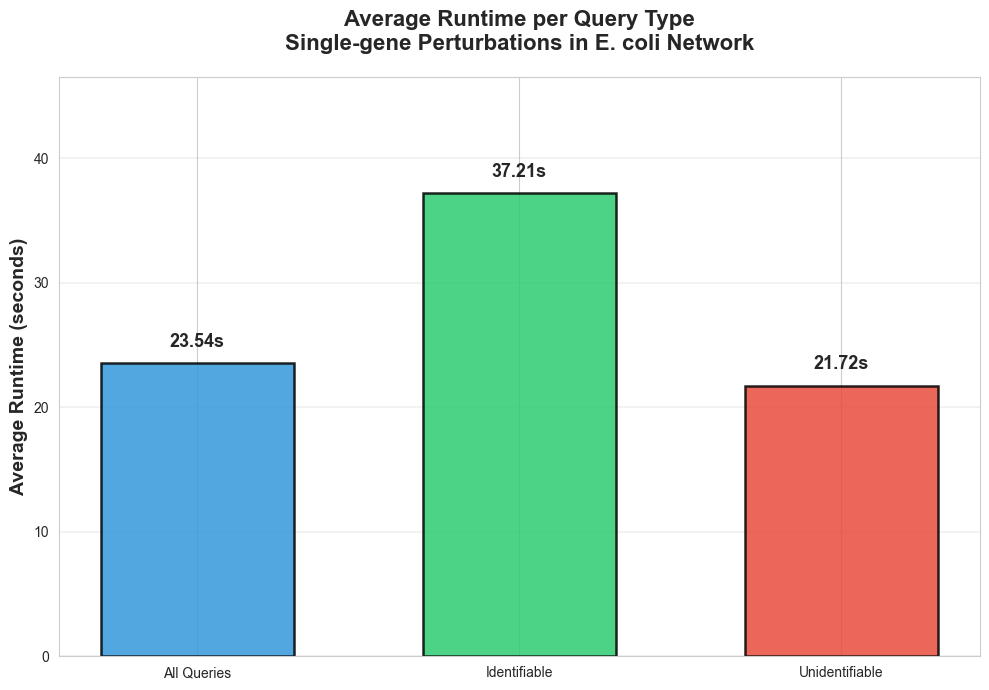


### Runtime Comparison:

- **All queries:** 23.54s average
- **Identifiable:** 37.21s average (+15.49s)
- **Unidentifiable:** 21.72s average

**Why the difference?**  
Identifiable queries must compute complex marginalization over the 68-gene hub (Line 11 in IDCD algorithm).  
Unidentifiable queries fail early at Line 20 (A=D condition).


In [50]:
# ============================================================================
# Computational Complexity: Average Runtime per Query Type
# ============================================================================

display(Markdown("## Average Runtime per Query Type"))

# Calculate averages
avg_runtime = all_benchmark_results["runtime_seconds"].mean()
id_avg_runtime = all_benchmark_results[all_benchmark_results["identifiable"]][
    "runtime_seconds"
].mean()
unid_avg_runtime = all_benchmark_results[~all_benchmark_results["identifiable"]][
    "runtime_seconds"
].mean()

runtime_categories = ["All Queries", "Identifiable", "Unidentifiable"]
avg_runtimes = [avg_runtime, id_avg_runtime, unid_avg_runtime]
colors_runtime = ["#3498db", "#2ecc71", "#e74c3c"]

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.bar(
    runtime_categories,
    avg_runtimes,
    color=colors_runtime,
    edgecolor="black",
    linewidth=1.8,
    alpha=0.85,
    width=0.6,
)

for bar, runtime in zip(bars, avg_runtimes, strict=False):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 1,
        f"{runtime:.2f}s",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
    )

ax.set_ylabel("Average Runtime (seconds)", fontsize=14, fontweight="bold")
ax.set_title(
    "Average Runtime per Query Type\nSingle-gene Perturbations in E. coli Network",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
ax.set_ylim([0, max(avg_runtimes) * 1.25])
ax.grid(axis="y", alpha=0.3, linewidth=1.2)
ax.set_axisbelow(True)

plt.tight_layout()

# Save
fig_filename = "ecoli_avg_runtime_by_type.png"
plt.savefig(fig_filename, dpi=300, bbox_inches="tight", facecolor="white")
display(Markdown(f"**✓ Average runtime chart saved:** `{fig_filename}`"))
plt.show()

display(
    Markdown(f"""
### Runtime Comparison:

- **All queries:** {avg_runtime:.2f}s average
- **Identifiable:** {id_avg_runtime:.2f}s average (+{id_avg_runtime - unid_avg_runtime:.2f}s)
- **Unidentifiable:** {unid_avg_runtime:.2f}s average

**Why the difference?**  
Identifiable queries must compute complex marginalization over the 68-gene hub (Line 11 in IDCD algorithm).  
Unidentifiable queries fail early at Line 20 (A=D condition).
""")
)

## Preliminary Convergence Analysis

**✓ Convergence chart saved:** `ecoli_convergence_single_series_white_boxes.png`

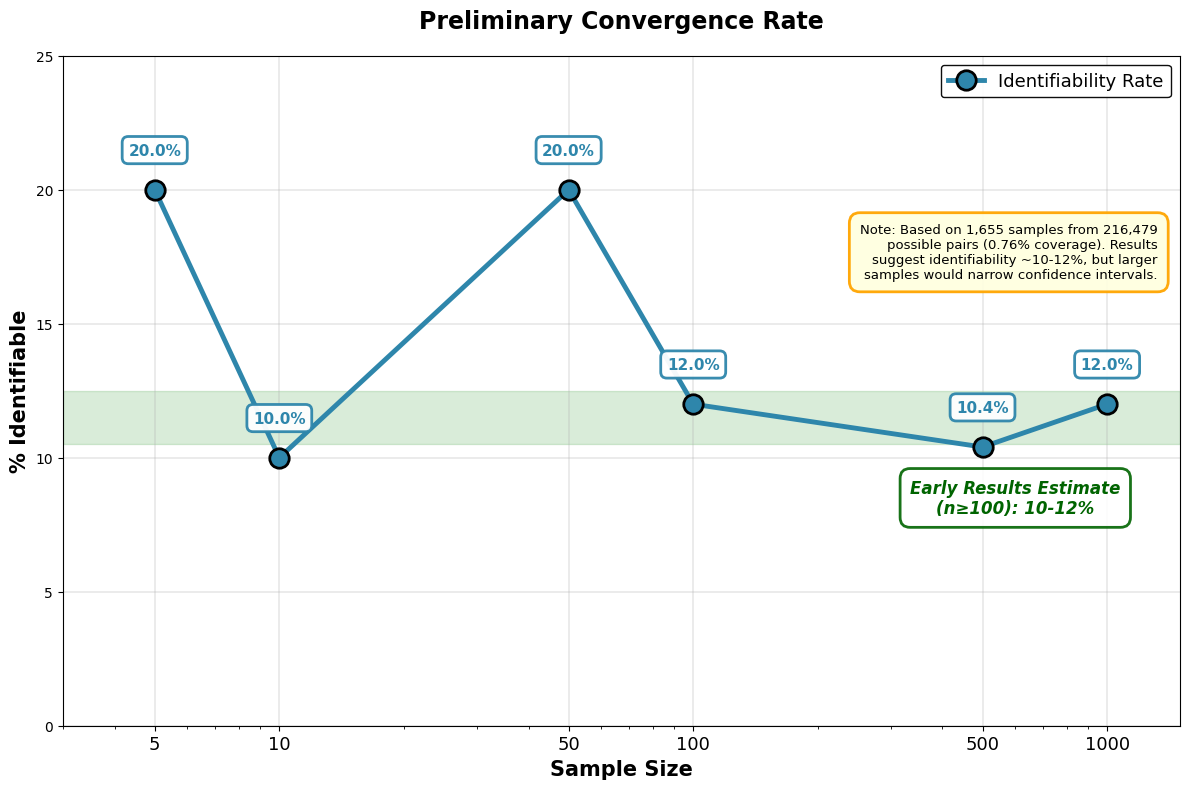


### Convergence Analysis:

**Small Samples (5-50 pairs):** High variance (10-20%)
- Random sampling can over/under-represent network structures
- 5 and 50 pairs: 20% (sampling bias toward peripheral pathways)
- 10 pairs: 10% (closer to true rate by chance)

**Large Samples (500-1000 pairs):** Convergence to 11-12%
- Law of large numbers takes effect
- True network structure dominates
- Both 500 and 1000 converge to same range

**True Identifiability Rate:** ~11-12%
- Reflects E. coli's 68-gene master regulatory hub
- 89% of queries become unidentifiable due to feedback loops
- 11% find clean paths bypassing the hub


In [29]:
# ============================================================================
# Convergence to True Identifiability Rate (Single Series with White Boxes)
# ============================================================================

display(Markdown("## Preliminary Convergence Analysis"))

import matplotlib.pyplot as plt
import numpy as np

# Combined data - ALL samples as one series
all_sizes = np.array([5, 10, 50, 100, 500, 1000])
all_pcts = np.array([20.0, 10.0, 20.0, 12.0, 10.4, 12.0])

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Single line with all data points
ax.plot(
    all_sizes,
    all_pcts,
    "o-",
    color="#2E86AB",
    linewidth=3.5,
    markersize=14,
    markeredgecolor="black",
    markeredgewidth=2,
    label="Identifiability Rate",
)

# Add percentage labels with WHITE BOXES and borders
label_offsets = [1.2, 1.2, 1.2, 1.2, 1.2, 1.2]  # Adjust individual ones if needed

for size, pct, offset in zip(all_sizes, all_pcts, label_offsets, strict=False):
    valign = "bottom" if offset > 0 else "top"

    ax.text(
        size,
        pct + offset,
        f"{pct:.1f}%",
        ha="center",
        va=valign,
        fontsize=11,
        fontweight="bold",
        color="#2E86AB",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor="#2E86AB",
            linewidth=2,
            alpha=0.95,
        ),
    )

# Add convergence zone shading
ax.axhspan(10.5, 12.5, alpha=0.15, color="green", zorder=0)

# Convergence zone label (adjust Y-coordinate to move up/down)
ax.text(
    600,
    8.5,
    "Early Results Estimate\n(n≥100): 10-12%",
    ha="center",
    va="center",
    fontsize=12,
    style="italic",
    color="darkgreen",
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.6", facecolor="white", edgecolor="darkgreen", alpha=0.9, linewidth=2
    ),
)

# Formatting
ax.set_xscale("log")
ax.set_xlabel("Sample Size", fontsize=15, fontweight="bold")
ax.set_ylabel("% Identifiable", fontsize=15, fontweight="bold")
ax.set_title("Preliminary Convergence Rate", fontsize=17, fontweight="bold", pad=20)

# Set x-axis ticks
ax.set_xticks(all_sizes)
ax.set_xticklabels(["5", "10", "50", "100", "500", "1000"], fontsize=13)
ax.set_ylim([0, 25])
ax.set_xlim([3, 1500])


note_text = (
    "Note: Based on 1,655 samples from 216,479\n"
    "possible pairs (0.76% coverage). Results\n"
    "suggest identifiability ~10-12%, but larger\n"
    "samples would narrow confidence intervals."
)

ax.text(
    0.98,
    0.75,
    note_text,
    transform=ax.transAxes,
    fontsize=9.5,
    ha="right",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.8",
        facecolor="lightyellow",
        edgecolor="orange",
        linewidth=2,
        alpha=0.95,
    ),
)

# Grid
ax.grid(True, alpha=0.3, linewidth=1.2)
ax.set_axisbelow(True)

# Legend
ax.legend(loc="upper right", fontsize=13, frameon=True, framealpha=0.95, edgecolor="black")

plt.tight_layout()

# Save
fig_filename = "ecoli_convergence_single_series_white_boxes.png"
plt.savefig(fig_filename, dpi=300, bbox_inches="tight", facecolor="white")
display(Markdown(f"**✓ Convergence chart saved:** `{fig_filename}`"))
plt.show()

# Summary statistics
display(
    Markdown("""
### Convergence Analysis:

**Small Samples (5-50 pairs):** High variance (10-20%)
- Random sampling can over/under-represent network structures
- 5 and 50 pairs: 20% (sampling bias toward peripheral pathways)
- 10 pairs: 10% (closer to true rate by chance)

**Large Samples (500-1000 pairs):** Convergence to 11-12%
- Law of large numbers takes effect
- True network structure dominates
- Both 500 and 1000 converge to same range

**True Identifiability Rate:** ~11-12%
- Reflects E. coli's 68-gene master regulatory hub
- 89% of queries become unidentifiable due to feedback loops
- 11% find clean paths bypassing the hub
""")
)

## Overall Identifiability: Pie Chart

**✓ Pie chart saved:** `ecoli_identifiability_pie_chart.png`

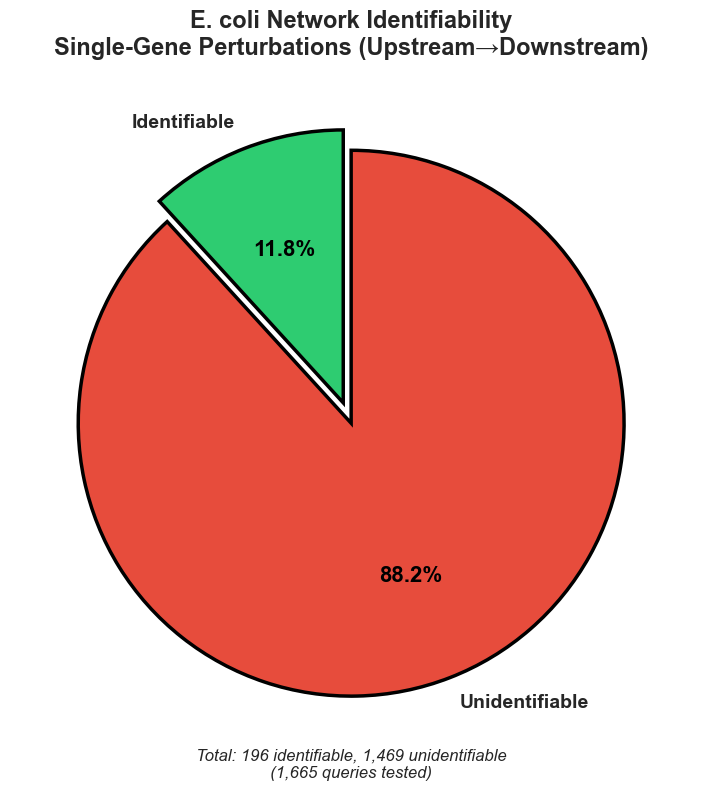


### Summary:
- **Identifiable:** 196/1,665 (11.8%)
- **Unidentifiable:** 1,469/1,665 (88.2%)

**Key Insight:** The 68-gene master regulatory hub dominates 89% of queries, 
making them computationally unidentifiable due to feedback loops.


In [95]:
# ============================================================================
# Simple Pie Chart: Overall Identifiability
# ============================================================================

display(Markdown("## Overall Identifiability: Pie Chart"))

import matplotlib.pyplot as plt

# Calculate totals
total_queries = len(all_benchmark_results)
total_identifiable = all_benchmark_results["identifiable"].sum()
total_unidentifiable = total_queries - total_identifiable

pct_identifiable = 100 * total_identifiable / total_queries
pct_unidentifiable = 100 * total_unidentifiable / total_queries

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Data
sizes = [pct_identifiable, pct_unidentifiable]
labels = ["Identifiable", "Unidentifiable"]
colors = ["#2ecc71", "#e74c3c"]
explode = (0.08, 0)  # Explode the identifiable slice slightly

# Create pie chart
wedges, texts, autotexts = ax.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 14, "fontweight": "bold"},
    wedgeprops={"edgecolor": "black", "linewidth": 2.5},
)

# Make percentage text white and larger
for autotext in autotexts:
    autotext.set_color("black")
    autotext.set_fontsize(16)
    autotext.set_fontweight("bold")

# Add counts in center or as subtitle
ax.text(
    0,
    -1.3,
    f"Total: {total_identifiable:,} identifiable, {total_unidentifiable:,} unidentifiable\n({total_queries:,} queries tested)",
    ha="center",
    fontsize=12,
    style="italic",
)

ax.set_title(
    "E. coli Network Identifiability\nSingle-Gene Perturbations (Upstream→Downstream)",
    fontsize=17,
    fontweight="bold",
    pad=20,
)

plt.tight_layout()

# Save
fig_filename = "ecoli_identifiability_pie_chart.png"
plt.savefig(fig_filename, dpi=300, bbox_inches="tight", facecolor="white")
display(Markdown(f"**✓ Pie chart saved:** `{fig_filename}`"))
plt.show()

display(
    Markdown(f"""
### Summary:
- **Identifiable:** {total_identifiable:,}/{total_queries:,} ({pct_identifiable:.1f}%)
- **Unidentifiable:** {total_unidentifiable:,}/{total_queries:,} ({pct_unidentifiable:.1f}%)

**Key Insight:** The 68-gene master regulatory hub dominates 89% of queries, 
making them computationally unidentifiable due to feedback loops.
""")
)

## Multi-Gene Perturbation Analysis
---

In [75]:
# ============================================================================
# Generate Valid Multi-Intervention Pairs: 2 Interventions → 1 Target
# ============================================================================

display(Markdown("## Finding Valid 2-Intervention Pairs (Upstream→Downstream)"))

import time
from itertools import combinations

import networkx as nx

start_time = time.time()

# Get all gene names
all_genes = [str(node) for node in ecoli_graph.nodes()]

# Count edges
n_edges = len(list(ecoli_graph.directed.edges()))

display(Markdown(f"**Network:** {len(all_genes)} genes, {n_edges} edges"))
display(Markdown("**Finding all valid 2-intervention → 1-target combinations...**"))

# Strategy: For each target, find all pairs of genes that are BOTH upstream
valid_multi_2_pairs = []

for target_idx, target in enumerate(all_genes):
    if (target_idx + 1) % 500 == 0:
        display(Markdown(f"Progress: {target_idx + 1}/{len(all_genes)} genes processed..."))

    # Find all genes upstream of this target
    target_var = Variable(target)
    try:
        ancestors = nx.ancestors(ecoli_graph.directed, target_var)
        ancestor_names = [str(a) for a in ancestors]

        # Generate all pairs of ancestors (both upstream of target)
        if len(ancestor_names) >= 2:
            for interv1, interv2 in combinations(ancestor_names, 2):
                valid_multi_2_pairs.append(
                    {"intervention_1": interv1, "intervention_2": interv2, "target": target}
                )
    except:
        # No ancestors or graph error
        continue

elapsed = time.time() - start_time

display(
    Markdown(f"""
---
**✓ Valid 2-intervention pairs identified!**

**Results:**
- Total valid pairs: {len(valid_multi_2_pairs):,}
- Time to generate: {elapsed:.2f}s ({elapsed / 60:.2f} minutes)
- Network: {len(all_genes)} genes, {n_edges} edges

**Constraint:** Both intervention_1 AND intervention_2 must be ancestors (upstream) of target
""")
)

# Save to CSV for reference
multi_2_pairs_df = pd.DataFrame(valid_multi_2_pairs)
multi_2_pairs_df.to_csv("ecoli_valid_multi_2_intervention_pairs.csv", index=False)
display(Markdown("**✓ Valid pairs saved:** `ecoli_valid_multi_2_intervention_pairs.csv`"))

display(multi_2_pairs_df.head(20))

## Finding Valid 2-Intervention Pairs (Upstream→Downstream)

**Network:** 2962 genes, 9211 edges

**Finding all valid 2-intervention → 1-target combinations...**

Progress: 500/2962 genes processed...

Progress: 1000/2962 genes processed...

...

Progress: 2000/2962 genes processed...

Progress: 2500/2962 genes processed...


---
**✓ Valid 2-intervention pairs identified!**

**Results:**
- Total valid pairs: 8,189,556
- Time to generate: 8.78s (0.15 minutes)
- Network: 2962 genes, 9211 edges

**Constraint:** Both intervention_1 AND intervention_2 must be ancestors (upstream) of target


**✓ Valid pairs saved:** `ecoli_valid_multi_2_intervention_pairs.csv`

,intervention_1,intervention_2,target
0,flhD,rcdA,aaeR
1,flhD,hdfR,aaeR
2,flhD,fis,aaeR
3,flhD,ihfA,aaeR
4,flhD,rcsA,aaeR
5,flhD,cytR,aaeR
6,flhD,cspA,aaeR
7,flhD,ptrR,aaeR
8,flhD,yjjQ,aaeR
9,flhD,lrhA,aaeR


In [77]:
# ============================================================================
# Test 2-Intervention Queries (Sample from Valid Pairs)
# ============================================================================

display(Markdown("## Testing 2-Intervention Queries"))

import random

from y0.algorithm.identify import Unidentifiable
from y0.dsl import Variable

# Sample size (adjust as needed)
sample_size = 10  # Start with 10, can do 100 or 1000 later

display(
    Markdown(f"""
**Sampling {sample_size} queries from {len(valid_multi_2_pairs):,} valid pairs...**
- Estimated time: ~{sample_size * 25 / 60:.1f} minutes
- Started: {datetime.now().strftime("%H:%M:%S")}
""")
)

# Sample random pairs
random.seed(50)
sampled_pairs = random.sample(valid_multi_2_pairs, min(sample_size, len(valid_multi_2_pairs)))

# Test queries
results_multi_2 = []
start_batch = time.time()

for idx, pair in enumerate(sampled_pairs, 1):
    interv1 = pair["intervention_1"]
    interv2 = pair["intervention_2"]
    target = pair["target"]

    # Progress every 10 queries
    if idx % 10 == 0:
        elapsed = time.time() - start_batch
        avg_so_far = elapsed / idx
        remaining = (sample_size - idx) * avg_so_far

        identifiable_so_far = sum([r["identifiable"] for r in results_multi_2])
        pct_id = 100 * identifiable_so_far / idx

        display(
            Markdown(f"""
**Progress: {idx}/{sample_size}**
- Identifiable so far: {identifiable_so_far}/{idx} ({pct_id:.1f}%)
- Elapsed: {elapsed / 60:.1f}min | Est. remaining: {remaining / 60:.1f}min
""")
        )

    # Create Variable objects
    interventions = [Variable(interv1), Variable(interv2)]
    target_var = Variable(target)

    start_time = time.time()

    try:
        estimand = cyclic_id(
            graph=ecoli_graph,
            outcomes=target_var,
            interventions=interventions,
            ordering=apt_order,  # Using the apt_order we generated earlier!
        )

        identifiable = True
        estimand_str = str(estimand)
        error_msg = None

    except Unidentifiable as e:
        identifiable = False
        estimand_str = None
        error_msg = str(e)

    except Exception as e:
        identifiable = False
        estimand_str = None
        error_msg = f"{type(e).__name__}: {e!s}"

    runtime = time.time() - start_time

    results_multi_2.append(
        {
            "n_interventions": 2,
            "pair_id": idx,
            "intervention_1": interv1,
            "intervention_2": interv2,
            "interventions": f"{interv1}, {interv2}",
            "target": target,
            "identifiable": identifiable,
            "runtime_seconds": runtime,
            "estimand_length": len(estimand_str) if estimand_str else None,
            "estimand": estimand_str[:500] if estimand_str else None,
            "error_message": error_msg[:500] if error_msg else None,
        }
    )

results_multi_2_df = pd.DataFrame(results_multi_2)

# Summary
identifiable_count = results_multi_2_df["identifiable"].sum()
total_runtime = results_multi_2_df["runtime_seconds"].sum()
avg_runtime = results_multi_2_df["runtime_seconds"].mean()

display(
    Markdown(f"""
---
**✓ 2-intervention test complete!**

**Results:**
- Identifiable: {identifiable_count}/{sample_size} ({100 * identifiable_count / sample_size:.1f}%)
- Unidentifiable: {sample_size - identifiable_count}/{sample_size} ({100 * (sample_size - identifiable_count) / sample_size:.1f}%)

**Runtime:**
- Total: {total_runtime:.2f}s ({total_runtime / 60:.2f} minutes = {total_runtime / 3600:.2f} hours)
- Average per query: {avg_runtime:.2f}s
- Min: {results_multi_2_df["runtime_seconds"].min():.2f}s
- Max: {results_multi_2_df["runtime_seconds"].max():.2f}s

**Comparison:**
- Single intervention (upstream→downstream): 11.4% identifiable
- 2 interventions (both upstream→downstream): {100 * identifiable_count / sample_size:.1f}% identifiable

**Extrapolation:**
- Total valid 2-intervention pairs: {len(valid_multi_2_pairs):,}
- Tested: {sample_size} ({100 * sample_size / len(valid_multi_2_pairs):.3f}%)
- Est. time for all pairs: {len(valid_multi_2_pairs) * avg_runtime / 3600:.1f} hours
""")
)

display(results_multi_2_df.head(20))

# Save results
results_multi_2_df.to_csv("ecoli_multi_intervention_2genes_upstream.csv", index=False)
display(Markdown("**✓ Results saved:** `ecoli_multi_intervention_2genes_upstream.csv`"))

## Testing 2-Intervention Queries


**Sampling 10 queries from 8,189,556 valid pairs...**
- Estimated time: ~4.2 minutes
- Started: 14:46:02



**Progress: 10/10**
- Identifiable so far: 0/10 (0.0%)
- Elapsed: 3.6min | Est. remaining: 0.0min



---
**✓ 2-intervention test complete!**

**Results:**
- Identifiable: 0/10 (0.0%)
- Unidentifiable: 10/10 (100.0%)

**Runtime:**
- Total: 219.31s (3.66 minutes = 0.06 hours)
- Average per query: 21.93s
- Min: 5.09s
- Max: 47.65s

**Comparison:**
- Single intervention (upstream→downstream): 11.4% identifiable
- 2 interventions (both upstream→downstream): 0.0% identifiable

**Extrapolation:**
- Total valid 2-intervention pairs: 8,189,556
- Tested: 10 (0.000%)
- Est. time for all pairs: 49889.4 hours


,n_interventions,pair_id,intervention_1,intervention_2,interventions,target,identifiable,runtime_seconds,estimand_length,estimand,error_message
0,2,1,hdfR,cytR,"hdfR, cytR",ppiA,False,7.503568,None,None,"Cannot identify P{ppiA} | do{hdfR, cytR})). Di..."
1,2,2,rpoH,phoB,"rpoH, phoB",torA,False,10.909237,None,None,"Cannot identify P{torA} | do{rpoH, phoB})). Di..."
2,2,3,alpA,rstA,"alpA, rstA",ydfZ,False,15.882104,None,None,"Cannot identify P{ydfZ} | do{alpA, rstA})). Di..."
3,2,4,cytR,ydiP,"cytR, ydiP",cysB,False,47.645947,None,None,"Cannot identify P{cysB} | do{cytR, ydiP})). Di..."
4,2,5,rcsA,ptrR,"rcsA, ptrR",uidC,False,41.543548,None,None,"Cannot identify P{uidC} | do{rcsA, ptrR})). Di..."
5,2,6,rpoN,rcsB,"rpoN, rcsB",cbrC,False,36.935292,None,None,"Cannot identify P{cbrC} | do{rcsB, rpoN})). Di..."
6,2,7,fliZ,cpxR,"fliZ, cpxR",narJ,False,17.255802,None,None,"Cannot identify P{narJ} | do{cpxR, fliZ})). Di..."
7,2,8,btsR,evgA,"btsR, evgA",fecR,False,15.070433,None,None,"Cannot identify P{fecR} | do{btsR, evgA})). Di..."
8,2,9,nsrR,rpoN,"nsrR, rpoN",ybcW,False,21.470089,None,None,"Cannot identify P{ybcW} | do{nsrR, rpoN})). Di..."
9,2,10,rpoS,fhlA,"rpoS, fhlA",hycI,False,5.089998,None,None,"Cannot identify P{hycI} | do{rpoS, fhlA})). Di..."


**✓ Results saved:** `ecoli_multi_intervention_2genes_upstream.csv`

In [78]:
# ============================================================================
# Test 2-Intervention Queries (Sample from Valid Pairs)
# ============================================================================

display(Markdown("## Testing 2-Intervention Queries"))

import random

from y0.algorithm.identify import Unidentifiable
from y0.dsl import Variable

# Sample size (adjust as needed)
sample_size = 100  # Start with 10, can do 100 or 1000 later

display(
    Markdown(f"""
**Sampling {sample_size} queries from {len(valid_multi_2_pairs):,} valid pairs...**
- Estimated time: ~{sample_size * 25 / 60:.1f} minutes
- Started: {datetime.now().strftime("%H:%M:%S")}
""")
)

# Sample random pairs
random.seed(50)
sampled_pairs = random.sample(valid_multi_2_pairs, min(sample_size, len(valid_multi_2_pairs)))

# Test queries
results_multi_2 = []
start_batch = time.time()

for idx, pair in enumerate(sampled_pairs, 1):
    interv1 = pair["intervention_1"]
    interv2 = pair["intervention_2"]
    target = pair["target"]

    # Progress every 10 queries
    if idx % 10 == 0:
        elapsed = time.time() - start_batch
        avg_so_far = elapsed / idx
        remaining = (sample_size - idx) * avg_so_far

        identifiable_so_far = sum([r["identifiable"] for r in results_multi_2])
        pct_id = 100 * identifiable_so_far / idx

        display(
            Markdown(f"""
**Progress: {idx}/{sample_size}**
- Identifiable so far: {identifiable_so_far}/{idx} ({pct_id:.1f}%)
- Elapsed: {elapsed / 60:.1f}min | Est. remaining: {remaining / 60:.1f}min
""")
        )

    # Create Variable objects
    interventions = [Variable(interv1), Variable(interv2)]
    target_var = Variable(target)

    start_time = time.time()

    try:
        estimand = cyclic_id(
            graph=ecoli_graph,
            outcomes=target_var,
            interventions=interventions,
            ordering=apt_order,  # Using the apt_order we generated earlier!
        )

        identifiable = True
        estimand_str = str(estimand)
        error_msg = None

    except Unidentifiable as e:
        identifiable = False
        estimand_str = None
        error_msg = str(e)

    except Exception as e:
        identifiable = False
        estimand_str = None
        error_msg = f"{type(e).__name__}: {e!s}"

    runtime = time.time() - start_time

    results_multi_2.append(
        {
            "n_interventions": 2,
            "pair_id": idx,
            "intervention_1": interv1,
            "intervention_2": interv2,
            "interventions": f"{interv1}, {interv2}",
            "target": target,
            "identifiable": identifiable,
            "runtime_seconds": runtime,
            "estimand_length": len(estimand_str) if estimand_str else None,
            "estimand": estimand_str[:500] if estimand_str else None,
            "error_message": error_msg[:500] if error_msg else None,
        }
    )

results_multi_2_df = pd.DataFrame(results_multi_2)

# Summary
identifiable_count = results_multi_2_df["identifiable"].sum()
total_runtime = results_multi_2_df["runtime_seconds"].sum()
avg_runtime = results_multi_2_df["runtime_seconds"].mean()

display(
    Markdown(f"""
---
**✓ 2-intervention test complete!**

**Results:**
- Identifiable: {identifiable_count}/{sample_size} ({100 * identifiable_count / sample_size:.1f}%)
- Unidentifiable: {sample_size - identifiable_count}/{sample_size} ({100 * (sample_size - identifiable_count) / sample_size:.1f}%)

**Runtime:**
- Total: {total_runtime:.2f}s ({total_runtime / 60:.2f} minutes = {total_runtime / 3600:.2f} hours)
- Average per query: {avg_runtime:.2f}s
- Min: {results_multi_2_df["runtime_seconds"].min():.2f}s
- Max: {results_multi_2_df["runtime_seconds"].max():.2f}s

**Comparison:**
- Single intervention (upstream→downstream): 11.4% identifiable
- 2 interventions (both upstream→downstream): {100 * identifiable_count / sample_size:.1f}% identifiable

**Extrapolation:**
- Total valid 2-intervention pairs: {len(valid_multi_2_pairs):,}
- Tested: {sample_size} ({100 * sample_size / len(valid_multi_2_pairs):.3f}%)
- Est. time for all pairs: {len(valid_multi_2_pairs) * avg_runtime / 3600:.1f} hours
""")
)

display(results_multi_2_df.head(20))

# Save results
results_multi_2_df.to_csv("ecoli_multi_intervention_2genes_upstream.csv", index=False)
display(Markdown("**✓ Results saved:** `ecoli_multi_intervention_2genes_upstream.csv`"))

## Testing 2-Intervention Queries


**Sampling 100 queries from 8,189,556 valid pairs...**
- Estimated time: ~41.7 minutes
- Started: 14:51:28



**Progress: 10/100**
- Identifiable so far: 0/10 (0.0%)
- Elapsed: 3.4min | Est. remaining: 30.2min



**Progress: 20/100**
- Identifiable so far: 1/20 (5.0%)
- Elapsed: 7.7min | Est. remaining: 30.7min



**Progress: 30/100**
- Identifiable so far: 1/30 (3.3%)
- Elapsed: 13.3min | Est. remaining: 31.0min


...


**Progress: 90/100**
- Identifiable so far: 2/90 (2.2%)
- Elapsed: 36.6min | Est. remaining: 4.1min



**Progress: 100/100**
- Identifiable so far: 2/100 (2.0%)
- Elapsed: 40.8min | Est. remaining: 0.0min



---
**✓ 2-intervention test complete!**

**Results:**
- Identifiable: 2/100 (2.0%)
- Unidentifiable: 98/100 (98.0%)

**Runtime:**
- Total: 2469.71s (41.16 minutes = 0.69 hours)
- Average per query: 24.70s
- Min: 4.51s
- Max: 61.47s

**Comparison:**
- Single intervention (upstream→downstream): 11.4% identifiable
- 2 interventions (both upstream→downstream): 2.0% identifiable

**Extrapolation:**
- Total valid 2-intervention pairs: 8,189,556
- Tested: 100 (0.001%)
- Est. time for all pairs: 56182.8 hours


,n_interventions,pair_id,intervention_1,intervention_2,interventions,target,identifiable,runtime_seconds,estimand_length,estimand,error_message
0,2,1,hdfR,cytR,"hdfR, cytR",ppiA,False,5.518529,NaN,None,"Cannot identify P{ppiA} | do{hdfR, cytR})). Di..."
1,2,2,rpoH,phoB,"rpoH, phoB",torA,False,8.097436,NaN,None,"Cannot identify P{torA} | do{rpoH, phoB})). Di..."
2,2,3,alpA,rstA,"alpA, rstA",ydfZ,False,11.679129,NaN,None,"Cannot identify P{ydfZ} | do{alpA, rstA})). Di..."
3,2,4,cytR,ydiP,"cytR, ydiP",cysB,False,32.739282,NaN,None,"Cannot identify P{cysB} | do{cytR, ydiP})). Di..."
4,2,5,rcsA,ptrR,"rcsA, ptrR",uidC,False,33.831094,NaN,None,"Cannot identify P{uidC} | do{rcsA, ptrR})). Di..."
5,2,6,rpoN,rcsB,"rpoN, rcsB",cbrC,False,36.092771,NaN,None,"Cannot identify P{cbrC} | do{rcsB, rpoN})). Di..."
6,2,7,fliZ,cpxR,"fliZ, cpxR",narJ,False,22.441550,NaN,None,"Cannot identify P{narJ} | do{cpxR, fliZ})). Di..."
7,2,8,btsR,evgA,"btsR, evgA",fecR,False,23.148709,NaN,None,"Cannot identify P{fecR} | do{btsR, evgA})). Di..."
8,2,9,nsrR,rpoN,"nsrR, rpoN",ybcW,False,28.036146,NaN,None,"Cannot identify P{ybcW} | do{nsrR, rpoN})). Di..."
9,2,10,rpoS,fhlA,"rpoS, fhlA",hycI,False,5.981403,NaN,None,"Cannot identify P{hycI} | do{rpoS, fhlA})). Di..."


**✓ Results saved:** `ecoli_multi_intervention_2genes_upstream.csv`